# Competition Model: Fitting to Experimental Data

**Model:** Two proteins (A, B) competing for a limiting nuclear import factor

## Model Schematic

![Competition Model](diagram/competition_model.png)

The diagram shows protein A cycling between cytoplasmic free form ($A_f$), factor-bound complex ($AF$), and nuclear form ($A_n$). Protein B (not shown) follows identical kinetics. Both proteins compete for the limited factor F, creating competitive inhibition for nuclear import.

## Mathematical Derivation

### Model Description

We consider two proteins, A and B, that compete for a limiting assembly factor F that facilitates their nuclear import:

1. **Binding:** Both proteins bind the assembly factor in the cytoplasm with equal affinity
2. **Nuclear import:** Only protein-factor complexes are imported into the nucleus, at equal rates
3. **Factor recycling:** Upon import, the factor is released
4. **Differential degradation:** Proteins degrade in both compartments, with potentially different rates for A and B
5. **Protection:** When bound to the factor, proteins are protected from degradation
6. **Synthesis:** Both proteins are synthesised at the same constant rate

### Species

**Cytoplasm:** $A_f$, $B_f$, $F_f$ (free proteins/factor), $AF$, $BF$ (complexes)

**Nucleus:** $A_n$, $B_n$ (nuclear proteins)

### Reactions

**Binding equilibria and nuclear import:**

$$
\begin{aligned}
A_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} AF \xrightarrow{k_{\text{import}}} A_n + F_f \\
B_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} BF \xrightarrow{k_{\text{import}}} B_n + F_f
\end{aligned}
$$

**Degradation:**

$$
\begin{aligned}
A_f &\xrightarrow{\delta_f^A} \emptyset , \quad
B_f \xrightarrow{\delta_f^B} \emptyset \\
A_n &\xrightarrow{\delta_n^A} \emptyset ,  \quad
B_n \xrightarrow{\delta_n^B} \emptyset 
\end{aligned}
$$

**Synthesis:**

$$
\emptyset \xrightarrow{k_s} A_f, \quad \emptyset \xrightarrow{k_s} B_f
$$

### Quasi-Steady State Approximation

The complexes obey

$$
\frac{d(AF)}{dt} = k_{\text{on}} A_f F_f - (k_{\text{off}} + k_{\text{import}})\,AF ,
$$

and similarly for $BF$. We assume that both equilibrate much faster than the free pools,
so we set the derivatives $\frac{d(AF)}{dt}$ and $\frac{d(BF)}{dt}$ to zero and solve
algebraically:

$$
AF = \frac{A_f F_f}{K_M} , \qquad BF = \frac{B_f F_f}{K_M} ,
\qquad K_M = \frac{k_{\text{off}} + k_{\text{import}}}{k_{\text{on}}} ,
$$

where $K_M$ is the Michaelis constant.

To see when this is justified, hold $A_f$ and $B_f$ fixed and substitute
$F_f = F_{\text{total}} - AF - BF$. The pair of complex equations becomes

$$
\frac{d}{dt}\begin{pmatrix} AF \\ BF \end{pmatrix}
= k_{\text{on}} F_{\text{total}} \begin{pmatrix} A_f \\ B_f \end{pmatrix}
- \begin{pmatrix}
k_{\text{off}} + k_{\text{import}} + k_{\text{on}}A_f & k_{\text{on}}A_f \\
k_{\text{on}}B_f & k_{\text{off}} + k_{\text{import}} + k_{\text{on}}B_f
\end{pmatrix}
\begin{pmatrix} AF \\ BF \end{pmatrix} ,
$$

which is linear. Its relaxation is therefore a sum of two decaying exponentials, 
with rates given by the eigenvalues of the matrix above,

$$
\lambda_1 = k_{\text{off}} + k_{\text{import}} ,
\qquad
\lambda_2 = (k_{\text{off}} + k_{\text{import}})\left(1 + \frac{A_f + B_f}{K_M}\right) .
$$

Note that the matrix enters with a minus sign, so its eigenvalues are decay rates.
Since $\lambda_1 \leq \lambda_2$ always, $\lambda_1$ is the rate that limits how fast the
complexes equilibrate.

The eigenvector for $\lambda_1$ is $(1,-1)$, which corresponds to a balanced increase in $AF$
and decrease in $BF$ (i.e. exchange of $F$ from $B$ to $A$).
The eigenvector for $\lambda_2$ is proportional to $(A_f,B_f)$, which changes $F_f$ in either
direction depending on the sign.

In summary, on timescales greater than $\lambda_1$, we can approximate the following,

$$
AF = \frac{A_f F_f}{K_M} \qquad BF = \frac{B_f F_f}{K_M}
$$

### Conservation of Factor

$$
F_{\text{total}} = F_f + AF + BF = F_f\left(1 + \frac{A_f + B_f}{K_M}\right)
$$

Therefore:

$$
F_f = \frac{F_{\text{total}}}{1 + (A_f + B_f)/K_M} = \frac{F_{\text{total}}K_M}{K_M + A_f + B_f}
$$

and using the quasi-steady-state approximation above,
$$
AF = \varepsilon A_f , \quad BF = \varepsilon B_f ,
\qquad \textrm{where} \qquad
\varepsilon \equiv \frac{F_{\text{total}}}{K_M + A_f + B_f} .
$$



### Simplifying ODEs

The full set of equations for $A$ is,

$$
\begin{aligned}
\frac{dA_f}{dt} &= k_s - k_{\text{on}} A_f F_f + k_{\text{off}} AF - \delta_f^A A_f , \\[4pt]
\frac{d(AF)}{dt} &= k_{\text{on}} A_f F_f - (k_{\text{off}} + k_{\text{import}}) AF , \\[4pt]
\frac{dA_n}{dt} &= k_{\text{import}} AF - \delta_n^A A_n ,
\end{aligned}
$$

The equation for $d(AF)/dt$, rearranges to
$k_{\text{on}} A_f F_f = d(AF)/dt + (k_{\text{off}} + k_{\text{import}})AF$. Substituting this
into the $dA_f/dt$ equation, the $k_{\text{off}}$ terms cancel, leaving

$$
\frac{dA_f}{dt} = k_s - k_{\text{import}} AF - \delta_f^A A_f - \frac{d(AF)}{dt} .
$$

Before dropping the final term, we need to evaluate under what conditions it is much smaller
than the other terms in $\frac{dA_f}{dt}$.

With $D = K_M + A_f + B_f$, the quasi-steady-state solution above gives 
$AF = F_{\text{total}} A_f / D$ and its time derivative,

$$
\frac{d(AF)}{dt} = F_{\text{total}} \left[ \frac{1}{D}\frac{dA_f}{dt} - \frac{A_f}{D^2}\frac{dD}{dt} \right].
$$

Since $K_M$ is constant, $\dfrac{dD}{dt} = \dfrac{dA_f}{dt} + \dfrac{dB_f}{dt}$, giving

$$
\frac{d(AF)}{dt}
= F_{\text{total}} \left[ \frac{1}{D}\frac{dA_f}{dt}
- \frac{A_f}{D^2}\left( \frac{dA_f}{dt} + \frac{dB_f}{dt} \right) \right] .
$$

Collecting the $dA_f/dt$ terms over the common denominator $D^2$,

$$
\frac{d(AF)}{dt}
= \frac{F_{\text{total}}}{D^2} \left[ (D - A_f)\,\frac{dA_f}{dt} - A_f\,\frac{dB_f}{dt} \right] ,
$$

and substituting $D - A_f = K_M + B_f$ and $F_{\text{total}}/D = \varepsilon$,

$$
\frac{d(AF)}{dt}
= \varepsilon \left[ \frac{K_M + B_f}{D}\,\frac{dA_f}{dt}
- \frac{A_f}{D}\,\frac{dB_f}{dt} \right] .
$$

The two coefficients are non-negative and sum to $1$, since
$(K_M + B_f) + A_f = D$. The bracket is therefore a weighted average of $dA_f/dt$ and
$-\,dB_f/dt$, bounded by whichever is larger in magnitude:

$$
\left|\frac{d(AF)}{dt}\right|
\;\leq\; \varepsilon \max\left(\left|\frac{dA_f}{dt}\right|,\ \left|\frac{dB_f}{dt}\right|\right) .
$$

The free pools evolve on the slow timescale, so their derivatives are at most of the same order
as the other terms in the $dA_f/dt$ equation ($k_s$, $\delta_f^A A_f$, $k_{\text{import}}AF$). We
can therefore safely ignore the final term ($d(AF)/dt$) as long as $\varepsilon \ll 1$, which
corresponds to the regime where a negligible fraction of $A$ and $B$ are held in complex,

$$
\varepsilon = \frac{F_{\text{total}}}{K_M + A_f + B_f} \ll 1 .
$$

### Final system ODEs

With the above approximations, we substitute $AF = \frac{F_{\text{total}}A_f}{K_M + A_f + B_f}$
and $BF = \frac{F_{\text{total}}B_f}{K_M + A_f + B_f}$ to generate the final ODE system.

$$
\begin{aligned}
\frac{dA_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_f^A A_f, \\
\frac{dB_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_f^B B_f, \\
\frac{dA_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_n^A A_n, \\
\frac{dB_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_n^B B_n.
\end{aligned}
$$

The conditions that we need to verify are:
> **(i) Timescale separation**. $\lambda_1 \gg$ every slow rate in the system:
> $k_s / X_f$, $\delta_f^A$, $\delta_f^B$, $\delta_n^A$, $\delta_n^B$. This is what allows the
> complexes to be replaced by their algebraic values.
>
> **(ii) Negligible sequestration**. $\varepsilon \ll 1$. This is what allows
> $d(AF)/dt$ to be dropped from the free-protein equation, and it sets the residual error of
> the reduction.



### Identifiability and the cytoplasmic:nuclear POLR2A constraint

$k_{\text{import}}$ and $F_{\text{total}}$ enter the reduced ODEs only as the product
$V_{\max} = k_{\text{import}} F_{\text{total}}$, so we cannot uniquely determine them from nuclear
data alone. We therefore fit $V_{\max}$ directly.

However, $F_{\text{total}}$ determines how much of $A$ and $B$ is bound versus free in the cytoplasm,
so its value is not unconstrained ($AF = A_f F_{\text{total}} / (K_M + A_f + B_f)$). We therefore
fix it using a cytoplasmic:nuclear POLR2A ratio measured from experiments,

$$
\frac{A_f + AF}{A_n} = R_{\mathrm{cyt}}
\qquad\Longrightarrow\qquad
F_{\text{total}} = \frac{(K_M + A_f + B_f)\,(R_{\mathrm{cyt}} A_n - A_f)}{A_f}
$$

Because $A_f$, $B_f$ and $A_n$ depend only on
$(k_s, V_{\max}, K_M, \delta_f^A, \delta_f^B, \delta_n^A)$ and not on $F_{\text{total}}$
($F_{\text{total}}$ enters these ODEs only as part of $V_{\max}$), this can be solved exactly at
each fit evaluation rather than fitted.

The measurement then constrains the fit through two conditions. Both are lower bounds on
$F_{\text{total}}$, since $D = K_M + A_f + B_f$ and $A_f$ are positive:

> **(i) Feasibility:** $F_{\text{total}} > 0$, equivalently $A_f < R_{\mathrm{cyt}} A_n$. The free
> pool alone must not already account for the entire measured cytoplasmic signal, or no
> positive $F_{\text{total}}$ exists.
>
> **Practical floor:** $F_{\text{total}} \ge \phi\, A_f$ (where $\phi$ is `F_TOTAL_FLOOR_FRAC`).
> Without this the fit tends towards $F_{\text{total}} \to 0$ with $k_{\text{import}} \to \infty$,
> an ever-smaller pool of factor cycling ever faster at fixed $V_{\max}$. Since
> $k_{\text{import}} = V_{\max}/F_{\text{total}}$ by definition, and $k_{\text{import}}$ is the
> rate at which a loaded factor–protein complex is imported, a floor on $F_{\text{total}}$ is
> equivalently a ceiling on how fast each factor molecule can cycle. The choice of $\phi$ is
> arbitrary and sets that ceiling, so the fitted $k_{\text{import}}$ should be read as an upper
> bound rather than an estimate.

### Flux

At steady state, synthesis of each protein balances two exits from the free cytoplasmic pool -
import into the nucleus, and degradation in the cytoplasm:

$$
k_s \;=\; \underbrace{\frac{V_{\max} X_f}{K_M + A_f + B_f}}_{\text{imported}} \;+\; \underbrace{\delta_f^X X_f}_{\text{degraded in cytoplasm}}
$$

so the imported fraction is the first term divided by $k_s$ and the degraded fraction is the second
term divided by $k_s$.



### Parameterization for Fitting

**Free parameters (5):**
- $k_s$ (synthesis rate)
- $V_{\max} = k_{\text{import}} F_{\text{total}}$ (maximal import flux)
- $K_M$ (Michaelis constant)
- $\delta_f^A$ (cytoplasmic degradation of A)
- $\delta_{\mathrm{degron}}^B$ (auxin degradation increment; added to both $\delta_f^B$ and $\delta_n^B$)

**Determined by the cytoplasmic:nuclear constraint:**
- $F_{\text{total}}$, and hence $k_{\text{import}} = V_{\max}/F_{\text{total}}$

**Fixed parameters (from experimental measurements):**
- $\delta_n^A$ (nuclear removal rate for A) from bleach chase experiments
- $\delta_n^B = f_B \cdot \delta_n^A$ where $f_B = $ RFP/GFP normalization ratio (from steady-state)
- $R_{\mathrm{cyt}} = (A_f + AF)/A_n$ in unperturbed cells (`CYTO_NUC_RATIO`)

**Auxin perturbation:** additive in *both* compartments, $\delta_n^B \to \delta_n^B + \delta_{\mathrm{degron}}^B$ and $\delta_f^B \to \delta_f^B + \delta_{\mathrm{degron}}^B$, with $\delta_{\mathrm{degron}}^B$ fitted (also $\delta_f^B = \delta_f^A$ in the control condition)

**Experimental conditions:**
- **VEH_AUX (Inhibitor):** Start at control steady state, step-increase in B degradation upon 5-Ph-IAA addition.
- **AUX_VEH (Washout):** Start at perturbed steady state, step-decrease B degradation back to control upon 5-Ph-IAA removal.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.optimize import minimize, differential_evolution
from scipy.integrate import solve_ivp
import warnings
import time

from models import (
    competition_steady_state,
    max_system_rate,
    simulate_competition_trajectory,
)
from utils import (
    save_parameters,
    load_experimental_data,
    calculate_time_averages,
    plot_data_preview,
)

warnings.filterwarnings("ignore")

# Data directory (all input CSVs)
DATA_DIR = Path("../data")

# Small constant guarding ratio denominators
EPS_RATIO = 1e-12

# Random seed for reproducible fitting
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## Load Experimental Data

Loaded data for conditions: ['VEH_AUX', 'AUX_VEH']
Held out for validation:    ['VEH_VEH', 'AUX_AUX']

Data points per condition:
  VEH_AUX: 24 time points
  AUX_VEH: 24 time points


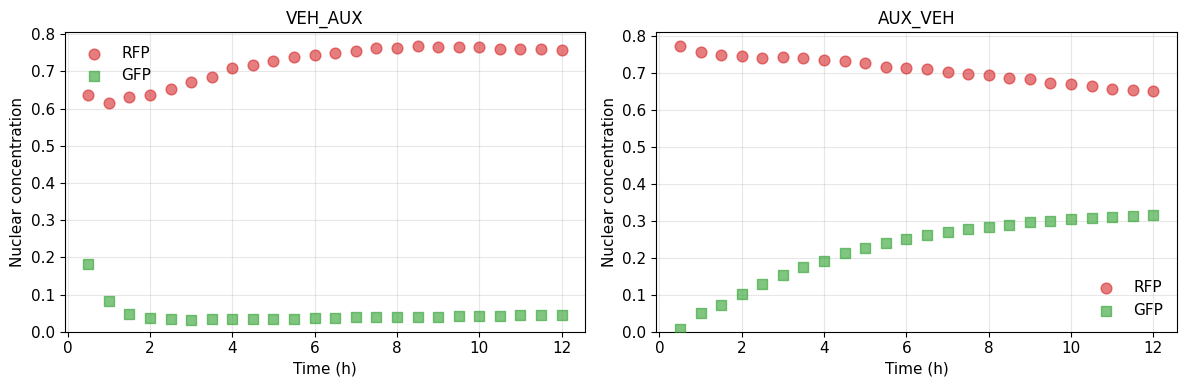

In [ ]:
# Data normalization factors (from steady-state mCherry/mClover ratio)
# Note this is not trivially calculated and requires equality of POLR2A IF
# between three cell lines: wild-type, mAC-POLR2A, mCherry-POLR2A.
RFP_NORMALIZATION = 0.5994
GFP_NORMALIZATION = 0.4153

# Load and normalize timecourse data
data_path = DATA_DIR / "mACmCh_LiveCellWashout_Values_ByExperiment.csv"
data = load_experimental_data(
    data_path, {"RFP": RFP_NORMALIZATION, "GFP": GFP_NORMALIZATION}
)

# Calculate time-averaged data for fitting
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours for fitting (where bleach correction
# is more manageable)
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

# Held-out conditions. Neither is used in fitting; both are pure steady states in
# the model and are compared against the final prediction at the end of the
# notebook.
HOLDOUT_CONDITIONS = ["VEH_VEH", "AUX_AUX"]
data_holdout = calculate_time_averages(data, HOLDOUT_CONDITIONS)
for code in HOLDOUT_CONDITIONS:
    data_holdout[code] = data_holdout[code][data_holdout[code]["time"] <= FIT_MAX_HOURS]

print(f"Loaded data for conditions: {list(data_averaged.keys())}")
print(f"Held out for validation:    {list(data_holdout.keys())}")
print(f"\nData points per condition:")
for code, df in data_averaged.items():
    print(f"  {code}: {len(df)} time points")

# Preview the data
plot_data_preview(data_averaged, fit_conditions)

## Fixed Parameters from Experimental Measurements

In [3]:
# Load bleach chase data to get measured removal rate
bleach_chase_path = DATA_DIR / "mACmCh_BleachChase_ByExperiment.csv"
bleach_chase_df = pd.read_csv(bleach_chase_path, index_col=0)

# Bleach chase was performed on mCherry-POLR2A (protein A) ONLY. The removal rate
# is unchanged by 5-Ph-IAA (see the bar plot in the next cell), so VEH and AUX are
# pooled into a single estimate of delta_n^A.
# Note this rate incorporates dilution due to cell growth.
DELTA_N_A = bleach_chase_df["RemovalRate_perhr"].mean()

# There is no bleach-chase measurement for mAC-POLR2A (protein B). We therefore
# ASSUME that the lower steady-state mClover level is entirely due to faster basal
# nuclear turnover, and set delta_n^B to whatever reproduces the measured
# steady-state ratio. This is an assumption, not a measurement: the control
# steady-state ratio is an input to the model, not a prediction of it.
DELTA_N_B_FACTOR = RFP_NORMALIZATION / GFP_NORMALIZATION
DELTA_N_B = DELTA_N_B_FACTOR * DELTA_N_A  # Basal nuclear removal rate for B

# Measured cytoplasmic:nuclear ratio of POLR2A in unperturbed cells.
# (A_f + AF)/A_n at the control steady state.
# Used to constrain F_total (see derivation above).
CYTO_NUC_RATIO = 0.2

# Two-sided constraint settings
CYTO_NUC_MARGIN = 0.98  # keep A_f strictly inside the feasible region

# Floor on the factor pool is specified as a fraction of the free protein
# pool: F_total >= phi * A_f. This is quite arbitrary. F should be limiting
# but not implausibly limiting. Equivalently this acts an upper limit on
# the import turnover number k_import = V_max / F_total.
# We choose F_total min to be 5 or 10% of A_f.
F_TOTAL_FLOOR_FRAC = 0.05

print("Fixed parameters and constraints:")
print(
    f"  δ_n^A (mCherry nuclear) = {DELTA_N_A:.4f} hr⁻¹ "
    f"(bleach chase, VEH+AUX pooled, n={len(bleach_chase_df)})"
)
print(f"  δ_n^B factor = {DELTA_N_B_FACTOR:.4f}  (assumed, not measured)")
print(f"  δ_n^B (control) = {DELTA_N_B:.4f} hr⁻¹")
print(f"  cytoplasmic:nuclear ratio (VEH) = {CYTO_NUC_RATIO}")
print(f"  F_total floor = {F_TOTAL_FLOOR_FRAC:.0%} of A_f")

Fixed parameters and constraints:
  δ_n^A (mCherry nuclear) = 0.1356 hr⁻¹ (bleach chase, VEH+AUX pooled, n=6)
  δ_n^B factor = 1.4433  (assumed, not measured)
  δ_n^B (control) = 0.1958 hr⁻¹
  cytoplasmic:nuclear ratio (VEH) = 0.2
  F_total floor = 5% of A_f


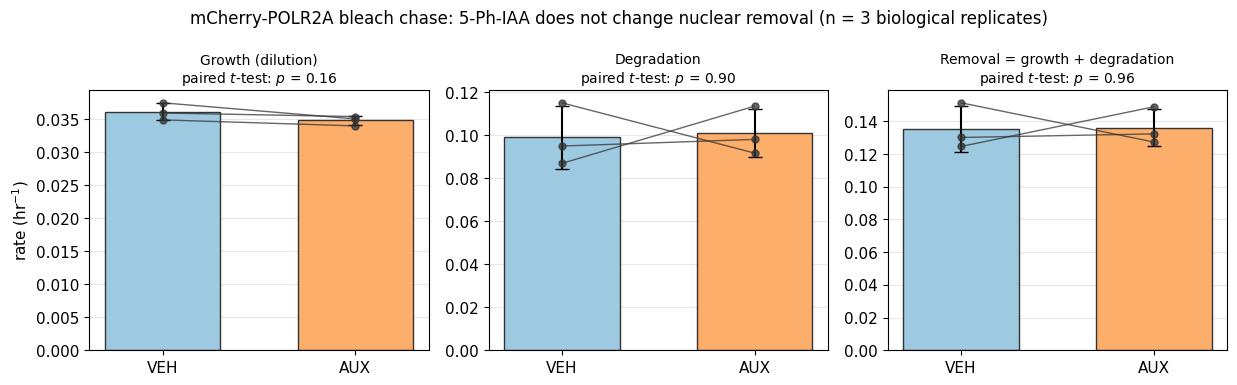

Pooled across treatments:
  Growth (dilution)                = 0.0355 ± 0.0012 hr⁻¹
  Degradation                      = 0.1001 ± 0.0117 hr⁻¹
  Removal = growth + degradation   = 0.1356 ± 0.0114 hr⁻¹

  δ_n^A (pooled removal rate)      = 0.1356 hr⁻¹
  removal half-life                = 5.11 h
  degradation half-life            = 6.92 h


In [4]:
# =============================================================================
# Justification for pooling VEH and AUX bleach-chase measurements
#
# delta_n^A is treated as unaffected by 5-Ph-IAA. That is the assumption that
# makes the model's buffering of nuclear A an import-flux effect rather than a
# stability effect, so it is worth showing explicitly.
# =============================================================================
from scipy.stats import ttest_rel

RATE_COLS = [
    ("GrowthRate_perhr", "Growth (dilution)"),
    ("DegradationRate_perhr", "Degradation"),
    ("RemovalRate_perhr", "Removal = growth + degradation"),
]
ORDER = ["VEH", "AUX"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
for ax, (col, title) in zip(axes, RATE_COLS):
    stats = bleach_chase_df.groupby("Treatment")[col].agg(["mean", "std"])
    ax.bar(
        ORDER,
        [stats.loc[t, "mean"] for t in ORDER],
        yerr=[stats.loc[t, "std"] for t in ORDER],
        color=["#9ecae1", "#fdae6b"],
        edgecolor="#333333",
        capsize=5,
        width=0.6,
        zorder=2,
    )
    # one connected pair of points per biological replicate
    wide = bleach_chase_df.pivot(index="Experiment", columns="Treatment", values=col)
    for _, row in wide.iterrows():
        ax.plot(
            ORDER,
            [row[t] for t in ORDER],
            "o-",
            color="#333333",
            lw=1.0,
            ms=5,
            alpha=0.75,
            zorder=3,
        )

    t_stat, p_val = ttest_rel(wide["AUX"], wide["VEH"])
    ax.set_title(f"{title}\npaired $t$-test: $p$ = {p_val:.2f}", fontsize=10)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("rate (hr$^{-1}$)")
fig.suptitle(
    "mCherry-POLR2A bleach chase: 5-Ph-IAA does not change nuclear removal "
    f"(n = {bleach_chase_df['Experiment'].nunique()} biological replicates)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("bleachchase_veh_vs_aux.pdf", bbox_inches="tight")
plt.show()

print("Pooled across treatments:")
for col, title in RATE_COLS:
    v = bleach_chase_df[col]
    print(f"  {title:32s} = {v.mean():.4f} ± {v.std():.4f} hr⁻¹")
print(f"\n  δ_n^A (pooled removal rate)      = {DELTA_N_A:.4f} hr⁻¹")
print(f"  removal half-life                = {np.log(2)/DELTA_N_A:.2f} h")
print(
    f"  degradation half-life            = "
    f"{np.log(2)/bleach_chase_df['DegradationRate_perhr'].mean():.2f} h"
)

## Define Fitting Objective

In [ ]:
# Relative weight of the RFP (mCherry) residuals in the VEH -> AUX (inhibitor)
# condition.
RFP_VEH_AUX_WEIGHT = 1

# The initial decay of GFP is more information-rich than the later part of the
# curve, so we increase its weight in the fit.
EARLY_GFP_WEIGHT = 3

# Penalty weights for the two-sided cytoplasmic constraint (dimensionless)
CYTO_NUC_PENALTY = 1e3
F_TOTAL_PENALTY = 1e3

# Reject parameter sets whose fastest rate constant exceeds this (hr^-1).
MAX_SYSTEM_RATE = 1e3


def solve_F_total(A_f, B_f, A_n, K_M, ratio=None):
    """
    F_total implied by the measured cytoplasmic:nuclear ratio.

    The trajectories depend on the factor only through V_max = k_import * F_total, so
    F_total is invisible to the nuclear fit. It is fixed instead by the cytoplasmic
    signal, which includes factor-bound protein AF = A_f F_total / (K_M + A_f + B_f):

        (A_f + AF) / A_n = ratio
        =>  F_total = (K_M + A_f + B_f) (ratio * A_n - A_f) / A_f

    Function returns 0.0 (rather than a NaN) when the free pool alone already
    accounts for the whole cytoplasmic signal, so that downstream arithmetic stays
    finite; the infeasibility is handled by the penalty in `constraint_penalty`
    instead.
    """
    if ratio is None:
        ratio = CYTO_NUC_RATIO
    if A_f <= 0 or A_n <= 0:
        return 0.0
    headroom = ratio * A_n - A_f
    if headroom <= 0:
        return 0.0
    return (K_M + A_f + B_f) * headroom / A_f


def constraint_penalty(A_f, B_f, A_n, K_M, ratio=None):
    """
    Two-sided penalty on the cytoplasmic constraint.

    (i)  Feasibility: the free pool must sit inside the measured cytoplasmic signal.
         A margin keeps the optimum off the boundary, where the quadratic penalty has
         zero gradient and would otherwise let the fit settle marginally outside.
    (ii) Floor on F_total: without it the fit escapes to F_total -> 0, which drives the
         import turnover number k_import = V_max / F_total to implausible values.
    """
    if ratio is None:
        ratio = CYTO_NUC_RATIO

    penalty = 0.0
    ratio_free = A_f / max(A_n, EPS_RATIO)

    excess = ratio_free - CYTO_NUC_MARGIN * ratio
    if excess > 0:
        penalty += CYTO_NUC_PENALTY * (excess / ratio) ** 2

    F_total = solve_F_total(A_f, B_f, A_n, K_M, ratio)
    F_floor = F_TOTAL_FLOOR_FRAC * A_f
    if F_total < F_floor:
        penalty += (
            F_TOTAL_PENALTY * ((F_floor - F_total) / max(F_floor, EPS_RATIO)) ** 2
        )

    return penalty


def objective_function(
    theta, data_averaged, return_predictions=False, cyto_nuc_ratio=None
):
    """
    Objective function for parameter fitting.

    Parameters
    ----------
    theta : array-like
        [k_s, V_max, K_M, delta_f_A, delta_n_B_degron]
        V_max = k_import * F_total is the maximal import flux; k_import and F_total
        are not separately identifiable from the nuclear data.
    data_averaged : dict
        Experimental data for each condition
    return_predictions : bool
        If True, return (loss, predictions) instead of just loss
    cyto_nuc_ratio : float, optional
        Measured cytoplasmic:nuclear ratio to impose. Defaults to CYTO_NUC_RATIO.
    """
    if cyto_nuc_ratio is None:
        cyto_nuc_ratio = CYTO_NUC_RATIO

    k_s, V_max, K_M, delta_f_A, delta_n_B_degron = theta

    # Parameter bounds check
    if any(x <= 0 for x in theta):
        return 1e10 if not return_predictions else (1e10, None)

    # Only the product V_max matters for the trajectories, so simulate with
    # F_total = 1 and k_import = V_max. The physical split is recovered afterwards
    # from the cytoplasmic:nuclear ratio via solve_F_total.
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }

    # Calculate degradation rates
    delta_n_A = DELTA_N_A
    delta_n_B_control = DELTA_N_B
    delta_n_B_perturbed = DELTA_N_B + delta_n_B_degron
    delta_f_B_control = delta_f_A
    delta_f_B_perturbed = delta_f_A + delta_n_B_degron

    # Steady states (solved algebraically - see models.competition_steady_state)
    try:
        ss_control = competition_steady_state(
            params, delta_f_B_control, delta_n_A, delta_n_B_control
        )
        ss_perturbed = competition_steady_state(
            params, delta_f_B_perturbed, delta_n_A, delta_n_B_perturbed
        )
    except Exception:
        return 1e10 if not return_predictions else (1e10, None)

    # Skip regions where the trajectory integration would be stiff
    rate = max(
        max_system_rate(params, ss_control, delta_f_B_control, delta_n_B_control),
        max_system_rate(params, ss_perturbed, delta_f_B_perturbed, delta_n_B_perturbed),
    )
    if not np.isfinite(rate) or rate > MAX_SYSTEM_RATE:
        return 1e10 if not return_predictions else (1e10, None)

    penalty = constraint_penalty(
        ss_control[0], ss_control[1], ss_control[2], K_M, cyto_nuc_ratio
    )

    # Simulate conditions
    conditions = {
        "VEH_AUX": (ss_control, delta_f_B_perturbed, delta_n_B_perturbed),
        "AUX_VEH": (ss_perturbed, delta_f_B_control, delta_n_B_control),
    }

    data_loss = 0.0
    predictions = {}

    for code, (y0, delta_f_B, delta_n_B) in conditions.items():
        if code not in data_averaged:
            continue

        data = data_averaged[code]
        t_max = data["time"].max()

        try:
            traj, times = simulate_competition_trajectory(
                params, delta_f_B, delta_n_A, delta_n_B, t_max, y0, n_points=100
            )
        except Exception:
            return 1e10 if not return_predictions else (1e10, None)

        # Interpolate to data time points
        A_n_interp = np.interp(data["time"], times, traj[2])
        B_n_interp = np.interp(data["time"], times, traj[3])

        # Per-point GFP weights: emphasise the early decay that constrains the degron
        gfp_weights = np.ones(len(data))
        if code == "VEH_AUX":
            gfp_weights[data["time"].to_numpy() <= 2.0] = EARLY_GFP_WEIGHT

        rfp_error = np.sum((A_n_interp - data["rfp"]) ** 2)
        gfp_error = np.sum(gfp_weights * (B_n_interp - data["gfp"]) ** 2)

        if code == "VEH_AUX":
            rfp_error *= RFP_VEH_AUX_WEIGHT

        data_loss += rfp_error + gfp_error

        if return_predictions:
            predictions[code] = {
                "time": times,
                "A_n": traj[2],
                "B_n": traj[3],
                "A_n_interp": A_n_interp,
                "B_n_interp": B_n_interp,
                "ss_control": ss_control,
                "ss_perturbed": ss_perturbed,
            }

    if return_predictions:
        return data_loss + penalty, predictions
    return data_loss + penalty


def fit_diagnostics(theta, cyto_nuc_ratio=None):
    """
    Steady-state diagnostics for a parameter set: the data-only loss (excluding the
    constraint penalty, so it is comparable across different imposed ratios), the
    recovered factor concentration, saturation and buffering.

    Reads the module-level `data_averaged`; the constraint is evaluated at the
    control steady state only (under auxin B_f collapses, D shrinks and A_f falls
    while A_n rises, so the feasibility bound is strictly looser there).
    """
    if cyto_nuc_ratio is None:
        cyto_nuc_ratio = CYTO_NUC_RATIO

    k_s, V_max, K_M, delta_f_A, degron = theta
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }
    ss_c = competition_steady_state(params, delta_f_A, DELTA_N_A, DELTA_N_B)
    ss_p = competition_steady_state(
        params, delta_f_A + degron, DELTA_N_A, DELTA_N_B + degron
    )
    A_f, B_f, A_n = ss_c[0], ss_c[1], ss_c[2]
    S = A_f + B_f
    F_total = solve_F_total(A_f, B_f, A_n, K_M, cyto_nuc_ratio)
    AF = A_f * F_total / (K_M + S)
    total_obj = objective_function(theta, data_averaged, cyto_nuc_ratio=cyto_nuc_ratio)
    penalty = constraint_penalty(A_f, B_f, A_n, K_M, cyto_nuc_ratio)

    return {
        "k_s": k_s,
        "V_max": V_max,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
        "delta_n_B_degron": degron,
        "data_loss": total_obj - penalty,
        "penalty": penalty,
        "A_f": A_f,
        "A_n": A_n,
        "AF": AF,
        "free_ratio": A_f / A_n,
        "cyto_nuc": (A_f + AF) / A_n,  # cytoplasmic to nuclear ratio (A)
        "F_total": F_total,
        "F_floor": F_TOTAL_FLOOR_FRAC * A_f,
        "k_import": V_max / F_total if F_total > 0 else np.inf,
        "saturation": S / (K_M + S),  # substrate / (K_M + substrate)
        "buffering": ss_p[2] / ss_c[2],  # relative increase in RFP at steady state
    }

## Define flux analysis and plotting helpers

In [22]:
def flux_partitioning(theta):
    """
    Fate of newly synthesised protein: imported vs degraded in the cytoplasm.

    At steady state k_s = V_max X_f/D + delta_f_X X_f for each protein, so the two
    terms give the fraction of synthesis reaching the nucleus and the fraction lost to
    cytoplasmic degradation. Equivalently f_import = delta_n_X X_n / k_s.
    """
    k_s, V_max, K_M, delta_f_A, degron = theta
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }

    rows = []
    for label, d_fB, d_nB in [
        ("control", delta_f_A, DELTA_N_B),
        ("+auxin", delta_f_A + degron, DELTA_N_B + degron),
    ]:
        ss = competition_steady_state(params, d_fB, DELTA_N_A, d_nB)
        A_f, B_f, A_n, B_n = ss
        D = K_M + A_f + B_f
        for name, X_f, d_fX, d_nX, X_n in [
            ("A (mCherry)", A_f, delta_f_A, DELTA_N_A, A_n),
            ("B (mClover)", B_f, d_fB, d_nB, B_n),
        ]:
            imported = V_max * X_f / D
            degraded = d_fX * X_f
            rows.append(
                {
                    "condition": label,
                    "protein": name,
                    "synthesis": k_s,
                    "import_flux": imported,
                    "cyto_deg_flux": degraded,
                    "f_imported": imported / k_s,
                    "f_cyto_degraded": degraded / k_s,
                    "check_balance": (imported + degraded) / k_s,  # should be 1
                    "check_nuclear": d_nX * X_n / imported,  # should be 1
                }
            )
    return pd.DataFrame(rows)


def summarise_sweep(diag_rows, thetas, key):
    """
    Combine per-point fit diagnostics with the flux partitioning for a sweep.

    Parameters
    ----------
    diag_rows : list of dict
        `fit_diagnostics` output for each sweep point, each carrying the swept
        value under `key`.
    thetas : dict
        {swept value -> theta}.
    key : str
        Name of the swept column ("R" or "K_M_fixed").
    """
    flux_rows = []
    for value in thetas:
        fp = flux_partitioning(thetas[value])
        rec = {key: value}
        for _, r in fp.iterrows():
            tag = "ctrl" if r["condition"] == "control" else "aux"
            prot = "A" if r["protein"].startswith("A") else "B"
            rec[f"f_imp_{prot}_{tag}"] = r["f_imported"]
            rec[f"f_deg_{prot}_{tag}"] = r["f_cyto_degraded"]
            rec[f"impflux_{prot}_{tag}"] = r["import_flux"]
        flux_rows.append(rec)

    out = pd.DataFrame(diag_rows).merge(pd.DataFrame(flux_rows), on=key)
    out = out.sort_values(key).reset_index(drop=True)

    # Derived quantities.
    # NOTE: impflux_A_aux / impflux_A_ctrl is identically equal to `buffering`
    # (= A_n_aux / A_n_ctrl), because delta_n^A is unchanged by auxin and
    # A_n = import_flux / delta_n^A at steady state.
    out["capacity_frac"] = out["V_max"] / (
        2 * out["k_s"]
    )  # import capacity / total synthesis
    for tag in ("ctrl", "aux"):
        out[f"share_A_{tag}"] = out[f"impflux_A_{tag}"] / (
            out[f"impflux_A_{tag}"] + out[f"impflux_B_{tag}"]
        )
    out["on_floor"] = out["F_total"] <= 1.01 * out["F_floor"]
    return out


def plot_sweep(
    summary, key, xlabel, logx=False, vline=None, suptitle=None, savepath=None
):
    """
    Ten-panel summary of a sweep. Identical layout for both sweeps so the two
    figures can be read side by side.
    """
    fig, axes = plt.subplots(2, 5, figsize=(21, 7.6))
    x = summary[key].to_numpy()

    def finish(ax, ylabel, title, legend=False, logy=False):
        if logx:
            ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        if vline is not None:
            ax.axvline(vline, ls="--", color="#333333", lw=1.2)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=11)
        ax.grid(alpha=0.3, which="both")
        if legend:
            ax.legend(frameon=False, fontsize=8)

    # --- row 0: fitted parameters ---------------------------------------
    ax = axes[0, 0]
    ax.plot(x, summary["data_loss"], "o-", color="#1f77b4", lw=2, ms=6)
    finish(ax, "data-only loss", "Fit quality")

    ax = axes[0, 1]
    ax.plot(x, summary["delta_n_B_degron"], "o-", color="#2ca02c", lw=2, ms=6)
    finish(ax, r"$\delta^B_{\mathrm{degron}}$  hr$^{-1}$", "Degron increment")

    ax = axes[0, 2]
    ax.plot(x, summary["k_s"], "o-", color="#7c2c91", lw=2, ms=6, label="$k_s$")
    ax.plot(x, summary["V_max"], "s-", color="#999999", lw=2, ms=6, label="$V_{max}$")
    finish(ax, "rate", "Synthesis and capacity", legend=True)

    ax = axes[0, 3]
    ax.plot(x, summary["delta_f_A"], "o-", color="#d62728", lw=2, ms=6)
    finish(ax, r"$\delta_f^A$  hr$^{-1}$", "Cytoplasmic degradation")

    ax = axes[0, 4]
    ax.plot(x, summary["K_M"], "o-", color="#7c2c91", lw=2, ms=6)
    ax.axhline(
        10 ** bounds_log[2][0],
        ls=":",
        color="#d62728",
        lw=1.5,
        label="search lower bound",
    )
    finish(ax, "$K_M$", "$K_M$", legend=True, logy=True)

    # --- row 1: mechanism -------------------------------------------------
    ax = axes[1, 0]
    ax.plot(
        x, summary["F_total"], "o-", color="#8c564b", lw=2, ms=6, label="$F_{total}$"
    )
    ax.plot(
        x,
        summary["F_floor"],
        "--",
        color="#d62728",
        lw=1.5,
        label=f"floor = {F_TOTAL_FLOOR_FRAC:.0%} of $A_f$",
    )
    finish(ax, "$F_{total}$", "Is the floor binding?", legend=True, logy=True)

    ax = axes[1, 1]
    ax.plot(
        x,
        summary["free_ratio"],
        "o-",
        color="#ff9896",
        lw=2,
        ms=6,
        label="$A_f/A_n$ (free)",
    )
    ax.plot(
        x,
        summary["cyto_nuc"],
        "s-",
        color="#8c564b",
        lw=2,
        ms=6,
        label="$(A_f+AF)/A_n$ (achieved)",
    )
    target = (
        summary["R"].to_numpy()
        if "R" in summary
        else np.full_like(x, CYTO_NUC_RATIO, dtype=float)
    )
    ax.plot(x, target, ":", color="#333333", lw=1.5, label="target $R_{cyt}$")
    finish(ax, "ratio to $A_n$", "Constraint satisfaction", legend=True)

    ax = axes[1, 2]
    ax.plot(
        x,
        100 * summary["saturation"],
        "o-",
        color="#7c2c91",
        lw=2,
        ms=6,
        label="saturation $S/(K_M{+}S)$",
    )
    ax.plot(
        x,
        100 * summary["capacity_frac"],
        "s-",
        color="#8c564b",
        lw=2,
        ms=6,
        label="$V_{max}/(2k_s)$",
    )
    ax.axhline(100, ls=":", color="#999999", lw=1.5)
    finish(ax, "%", "Saturation and capacity", legend=True)

    ax = axes[1, 3]
    ax.plot(
        x,
        100 * summary["f_imp_A_ctrl"],
        "o-",
        color="#1f77b4",
        lw=2,
        ms=6,
        label="A, control",
    )
    ax.plot(
        x,
        100 * summary["f_imp_A_aux"],
        "s--",
        color="#d62728",
        lw=2,
        ms=6,
        label="A, +auxin",
    )
    ax.plot(
        x,
        100 * summary["f_imp_B_aux"],
        "^--",
        color="#2ca02c",
        lw=2,
        ms=6,
        label="B, +auxin",
    )
    ax.set_ylim(0, 100)
    finish(
        ax, "% of synthesis imported", "Imported vs degraded in cytoplasm", legend=True
    )

    ax = axes[1, 4]
    ax.plot(
        x,
        summary["buffering"],
        "o-",
        color="#2ca02c",
        lw=2,
        ms=6,
        label="$A_n$ (+auxin / control)",
    )
    ax.axhline(1.0, ls=":", color="#999999", lw=1.5)
    ax2 = ax.twinx()
    ax2.plot(
        x,
        100 * summary["share_A_ctrl"],
        "s--",
        color="#08306b",
        lw=1.6,
        ms=5,
        label="A share, control",
    )
    ax2.plot(
        x,
        100 * summary["share_A_aux"],
        "^--",
        color="#6baed6",
        lw=1.6,
        ms=5,
        label="A share, +auxin",
    )
    ax2.set_ylabel("A's share of import flux (%)", color="#08306b")
    ax2.set_ylim(0, 100)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="lower left")
    finish(ax, "buffering of $A_n$", "Buffering and capacity reallocation")

    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, axes


def plot_sweep_fits(thetas, ratios, cbar_label, suptitle, logcm=True, savepath=None):
    """
    Model curves across a sweep, overlaid on the data.

    `thetas` maps swept value -> theta; `ratios` maps swept value -> the
    cytoplasmic:nuclear ratio to impose for that point (a constant for the K_M
    sweep, the swept value itself for the R_cyt sweep).
    """
    values = np.asarray(sorted(thetas))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    norm = (
        mcolors.LogNorm(vmin=values.min(), vmax=values.max())
        if logcm
        else plt.Normalize(vmin=values.min(), vmax=values.max())
    )
    cmap = plt.cm.viridis
    titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

    for ax, code_ in zip(axes, ["VEH_AUX", "AUX_VEH"]):
        d = data_averaged[code_]
        ax.scatter(d["time"], d["rfp"], color="#d62728", alpha=0.55, s=55, zorder=4)
        ax.scatter(
            d["time"], d["gfp"], color="#2ca02c", alpha=0.55, s=55, marker="s", zorder=4
        )
        for v in values:
            _, preds = objective_function(
                thetas[v],
                data_averaged,
                return_predictions=True,
                cyto_nuc_ratio=ratios[v],
            )
            col = cmap(norm(v))
            ax.plot(preds[code_]["time"], preds[code_]["A_n"], color=col, lw=1.8)
            ax.plot(
                preds[code_]["time"], preds[code_]["B_n"], color=col, lw=1.8, ls="--"
            )
        ax.set_xlabel("Time (h)")
        ax.set_title(titles[code_])
        ax.set_ylim(0, None)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Nuclear concentration")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label(cbar_label)
    fig.suptitle(suptitle, fontsize=13)
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, axes

## Run Optimization

In [ ]:
# Wide bounds. k_s, V_max, K_M and delta_f_A span orders of magnitude, so they are
# searched in log10 space; the decay rate for the degron is searched linearly.
bounds_log = [
    (-2, 2),  # log10 k_s
    (-2, 2),  # log10 V_max  (= k_import * F_total)
    (-9, 0),  # log10 K_M
    (-2, 2),  # log10 delta_f_A
    (0.1, 10.0),  # delta_n_B_degron
]

PARAM_NAMES = ["k_s", "V_max", "K_M", "delta_f_A", "delta_n_B_degron"]


def _to_linear(theta_log):
    """Map optimizer coordinates back to model parameters."""
    return np.append(10.0 ** np.asarray(theta_log[:4]), theta_log[4])


def _to_log(theta):
    """Map model parameters into optimizer coordinates."""
    return np.append(np.log10(np.asarray(theta[:4], dtype=float)), theta[4])


def _objective_log(theta_log, data_averaged, cyto_nuc_ratio=None):
    return objective_function(
        _to_linear(theta_log), data_averaged, cyto_nuc_ratio=cyto_nuc_ratio
    )


print("Running global optimization...")
result_global = differential_evolution(
    _objective_log,
    bounds_log,
    args=(data_averaged,),
    maxiter=500,
    popsize=20,
    seed=RANDOM_SEED,
    workers=1,
    updating="deferred",
    tol=1e-8,
)

print("\nRefining with local optimization...")
result_local = minimize(
    _objective_log,
    result_global.x,
    args=(data_averaged,),
    method="L-BFGS-B",
    bounds=bounds_log,
)

best_params_array = _to_linear(result_local.x)
best_loss = result_local.fun
k_s, V_max, K_M, delta_f_A, delta_n_B_degron = best_params_array

diag = fit_diagnostics(best_params_array)
F_TOTAL = diag["F_total"]
K_IMPORT = diag["k_import"]

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)
print(
    f"Total objective: {best_loss:.4e}   "
    f"(data {diag['data_loss']:.4e} + penalty {diag['penalty']:.2e})"
)
print(f"\nBest-fit parameters:")
print(f"  k_s       = {k_s:.4f} hr⁻¹")
print(f"  V_max     = {V_max:.4f}  (= k_import x F_total)")
print(f"  K_M       = {K_M:.6g}")
print(f"  delta_f_A = {delta_f_A:.4f} hr⁻¹")
print(f"  delta_n_B_degron = {delta_n_B_degron:.4f} hr⁻¹")

print(f"\nRecovered from the cytoplasmic:nuclear ratio (R = {CYTO_NUC_RATIO}):")
print(f"  F_total   = {F_TOTAL:.4g}   (floor = {diag['F_floor']:.4g})")
print(
    f"  k_import  = {K_IMPORT:.4g} hr⁻¹  "
    f"(one import per factor every {60/K_IMPORT:.1f} min)"
    if np.isfinite(K_IMPORT)
    else "  k_import  = inf"
)

print(f"\nControl steady state:")
print(f"  A_f = {diag['A_f']:.4f}   AF = {diag['AF']:.4f}   A_n = {diag['A_n']:.4f}")
print(f"  free pool A_f/A_n                = {diag['free_ratio']:.4f}")
print(
    f"  cytoplasmic:nuclear (A_f+AF)/A_n = {diag['cyto_nuc']:.4f}  (target {CYTO_NUC_RATIO})"
)
print(
    f"  saturation = {100*diag['saturation']:.1f}%   buffering = {diag['buffering']:.3f}"
)

if diag["penalty"] > 1e-6:
    print(
        f"\n  NOTE: constraint penalty is {diag['penalty']:.3g}, i.e. the fit is sitting"
    )
    print("  against one of the bounds. F_total is at its floor.")

Running global optimization...

Refining with local optimization...

OPTIMIZATION COMPLETE
Total objective: 7.6349e-02   (data 7.6349e-02 + penalty 1.76e-10)

Best-fit parameters:
  k_s       = 0.1530 hr⁻¹
  V_max     = 0.1637  (= k_import x F_total)
  K_M       = 1.13976e-09
  delta_f_A = 0.6043 hr⁻¹
  delta_n_B_degron = 2.0382 hr⁻¹

Recovered from the cytoplasmic:nuclear ratio (R = 0.2):
  F_total   = 0.005887   (floor = 0.005887)
  k_import  = 27.8 hr⁻¹  (one import per factor every 2.2 min)

Control steady state:
  A_f = 0.1177   AF = 0.0029   A_n = 0.6034
  free pool A_f/A_n                = 0.1951
  cytoplasmic:nuclear (A_f+AF)/A_n = 0.2000  (target 0.2)
  saturation = 100.0%   buffering = 1.328


## Save Parameters

In [8]:
# Package parameters for saving. k_import and F_total are stored so that
# k_import * F_total = V_max, which is what the model actually uses.
best_params = {
    "k_s": k_s,
    "V_max": V_max,
    "k_import": K_IMPORT,
    "F_total": F_TOTAL,
    "K_M": K_M,
    "delta_f_A": delta_f_A,
    "delta_n_B_degron": delta_n_B_degron,
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
    "cyto_nuc_ratio": CYTO_NUC_RATIO,
    "f_total_floor_frac": F_TOTAL_FLOOR_FRAC,
}

# Save to JSON
output_path = Path("fitted_parameters/competition_params.json")
save_parameters(best_params, output_path)
print(f"\nSaved parameters to: {output_path.resolve()}")


Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/competition_params.json


## Visualise Fits

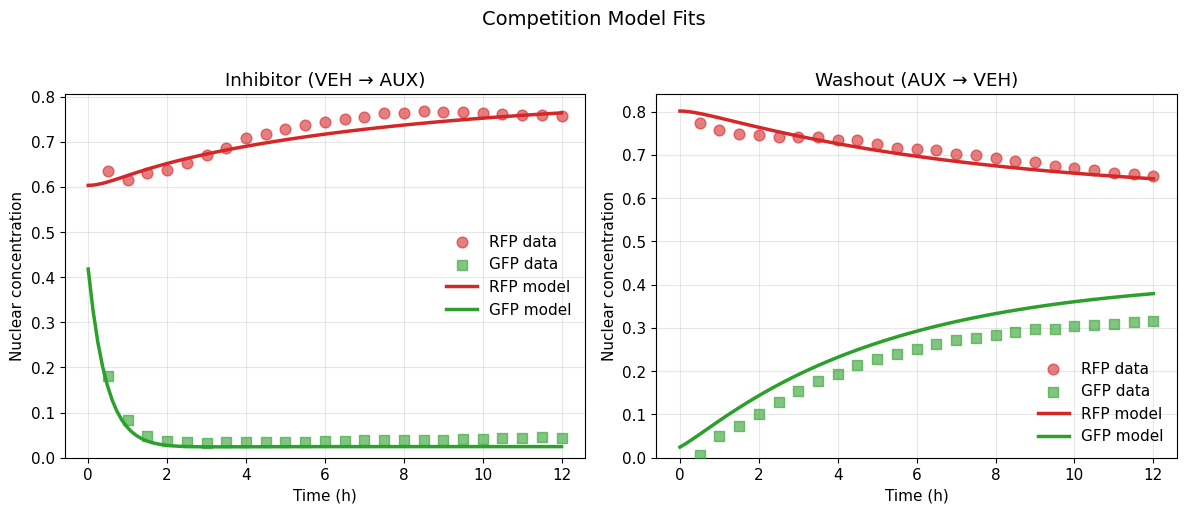

In [ ]:
# Get predictions with best parameters
_, predictions = objective_function(
    best_params_array, data_averaged, return_predictions=True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code_ in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code_]
    pred = predictions[code_]

    # Plot data
    ax.scatter(
        d["time"],
        d["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        label="RFP data",
        zorder=3,
    )
    ax.scatter(
        d["time"],
        d["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        label="GFP data",
        zorder=3,
    )

    # Plot model
    ax.plot(
        pred["time"], pred["A_n"], color=colors["rfp"], linewidth=2.5, label="RFP model"
    )
    ax.plot(
        pred["time"], pred["B_n"], color=colors["gfp"], linewidth=2.5, label="GFP model"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Nuclear concentration")
    ax.set_title(titles[code_])
    ax.legend(frameon=False)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

fig.suptitle("Competition Model Fits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Validation: Algebraic vs Integrated Steady State

`models.competition_steady_state` solves the steady state algebraically rather than integrating the
ODEs to $t = 200$ h. This cell verifies that simplification, at several $K_M$ spanning the
range used in the sweep below.

1. Compare the algebraic solution against `integrate_competition_to_steady_state`
2. Compare both the algebraic and steady-state integration against the endpoint of
   a long numerical integration started from an initial condition
   deliberately away from steady state;

      K_M  |alg - ODE ss|  |alg - traj end|     t(alg)   t(ODE ss)
  1.0e-09        5.19e-10          1.45e-09      0.08ms      1.37ms
  1.0e-06        5.19e-10          1.45e-09      0.03ms      1.24ms
  1.0e-03        6.50e-10          1.66e-07      0.02ms      1.13ms
  1.0e-01        2.64e-10          3.38e-09      0.02ms      1.38ms


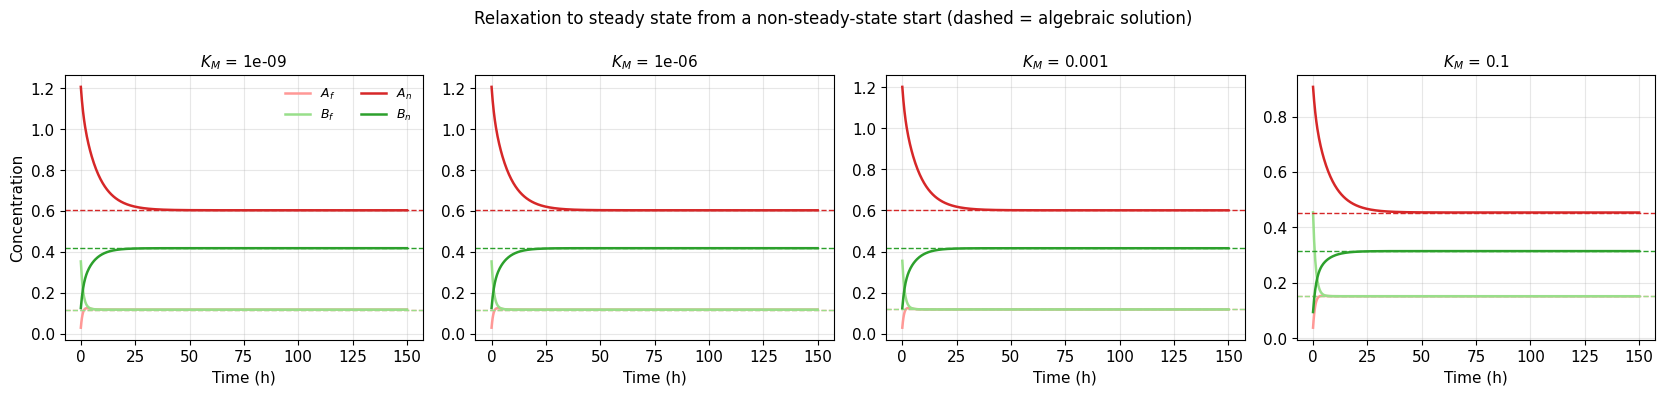

In [10]:
from models import integrate_competition_to_steady_state as _integrate_ss

VALIDATION_K_M = [1e-9, 1e-6, 1e-3, 1e-1]
Y0_FACTORS = np.array([0.25, 3.0, 2.0, 0.3])  # start well away from steady state
T_END_VALIDATION = 150.0

fig, axes = plt.subplots(1, len(VALIDATION_K_M), figsize=(4.2 * len(VALIDATION_K_M), 4))
axes = np.atleast_1d(axes)
labels = ["$A_f$", "$B_f$", "$A_n$", "$B_n$"]
colours = ["#ff9896", "#98df8a", "#d62728", "#2ca02c"]

print(
    f"{'K_M':>9} {'|alg - ODE ss|':>15} {'|alg - traj end|':>17} "
    f"{'t(alg)':>10} {'t(ODE ss)':>11}"
)

for ax, K_M_v in zip(axes, VALIDATION_K_M):
    p_v = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M_v,
        "delta_f_A": delta_f_A,
    }

    t0 = time.perf_counter()
    ss_alg = competition_steady_state(p_v, delta_f_A, DELTA_N_A, DELTA_N_B)
    t_alg = time.perf_counter() - t0

    t0 = time.perf_counter()
    ss_ode = _integrate_ss(p_v, delta_f_A, DELTA_N_A, DELTA_N_B)
    t_ode = time.perf_counter() - t0

    # Relax from an initial condition deliberately away from steady state.
    y0 = ss_alg * Y0_FACTORS
    traj, times = simulate_competition_trajectory(
        p_v, delta_f_A, DELTA_N_A, DELTA_N_B, T_END_VALIDATION, y0, n_points=600
    )

    for idx, (lab, col) in enumerate(zip(labels, colours)):
        ax.plot(times, traj[idx], color=col, lw=1.8, label=lab)
        ax.axhline(ss_alg[idx], color=col, ls="--", lw=1.0)

    ax.set_xlabel("Time (h)")
    ax.set_title(f"$K_M$ = {K_M_v:g}", fontsize=11)
    ax.grid(alpha=0.3)

    print(
        f"{K_M_v:9.1e} {np.max(np.abs(ss_alg - ss_ode)):15.2e} "
        f"{np.max(np.abs(ss_alg - traj[:, -1])):17.2e} "
        f"{1000*t_alg:9.2f}ms {1000*t_ode:9.2f}ms"
    )

axes[0].set_ylabel("Concentration")
axes[0].legend(frameon=False, fontsize=9, ncol=2)
fig.suptitle(
    "Relaxation to steady state from a non-steady-state start "
    "(dashed = algebraic solution)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Parameter dependence

### Dependence on $R_{\mathrm{cyt}}$

The measured cytoplasmic:nuclear ratio is an input, not a fitted quantity. We now examine
how the model fit changes when we alter its value. Here $R_{\mathrm{cyt}}$ is scanned from
0.05 to 0.5 and the model is re-fit at each value, with the same two-sided constraint applied
throughout.

In [19]:
R_VALUES = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

# Use `SCAN_DE_MAXITER` to alter global (differential evolution) optimisation.
SCAN_DE_MAXITER = 400
SCAN_DE_POPSIZE = 20

scan_rows = []
scan_thetas = {}
theta_prev = best_params_array.copy()

for R in R_VALUES:
    t0 = time.perf_counter()

    result_global_R = differential_evolution(
        _objective_log,
        bounds_log,
        args=(data_averaged, R),
        maxiter=SCAN_DE_MAXITER,
        popsize=SCAN_DE_POPSIZE,
        seed=RANDOM_SEED,
        workers=1,
        updating="deferred",
        tol=1e-6,
    )

    best = (np.inf, None)
    for x0 in [_to_linear(result_global_R.x), theta_prev, best_params_array]:
        try:
            res = minimize(
                _objective_log,
                _to_log(x0),
                args=(data_averaged, R),
                method="L-BFGS-B",
                bounds=bounds_log,
            )
        except Exception:
            continue
        if res.fun < best[0]:
            best = (res.fun, _to_linear(res.x))

    theta_best = best[1] if best[1] is not None else theta_prev
    scan_thetas[R] = theta_best
    theta_prev = theta_best

    d = fit_diagnostics(theta_best, cyto_nuc_ratio=R)
    d["R"] = R
    scan_rows.append(d)

    print(
        f"R = {R:5.3f}:  data loss = {d['data_loss']:.5f}  "
        f"K_M = {d['K_M']:.3g}  degron = {d['delta_n_B_degron']:.3f}  "
        f"F_total = {d['F_total']:.3g}"
        f"   [{time.perf_counter() - t0:.1f}s]"
    )

scan = summarise_sweep(scan_rows, scan_thetas, "R")
print("\nScan complete.")

R = 0.050:  data loss = 0.16568  K_M = 4.67e-09  degron = 2.775  F_total = 0.00157   [71.8s]
R = 0.100:  data loss = 0.11669  K_M = 5.14e-09  degron = 2.436  F_total = 0.00305   [49.0s]
R = 0.150:  data loss = 0.09162  K_M = 2.37e-09  degron = 2.203  F_total = 0.00448   [55.3s]
R = 0.200:  data loss = 0.07635  K_M = 1.14e-09  degron = 2.038  F_total = 0.00589   [45.5s]
R = 0.250:  data loss = 0.06624  K_M = 1.14e-09  degron = 1.915  F_total = 0.00727   [54.9s]
R = 0.300:  data loss = 0.05914  K_M = 0.00274  degron = 1.831  F_total = 0.00868   [86.1s]
R = 0.350:  data loss = 0.05312  K_M = 0.0115  degron = 1.779  F_total = 0.0102   [94.6s]
R = 0.400:  data loss = 0.04787  K_M = 0.0218  degron = 1.733  F_total = 0.0116   [92.1s]
R = 0.450:  data loss = 0.04340  K_M = 0.034  degron = 1.693  F_total = 0.0131   [71.8s]
R = 0.500:  data loss = 0.03968  K_M = 0.0479  degron = 1.658  F_total = 0.0146   [71.8s]

Scan complete.


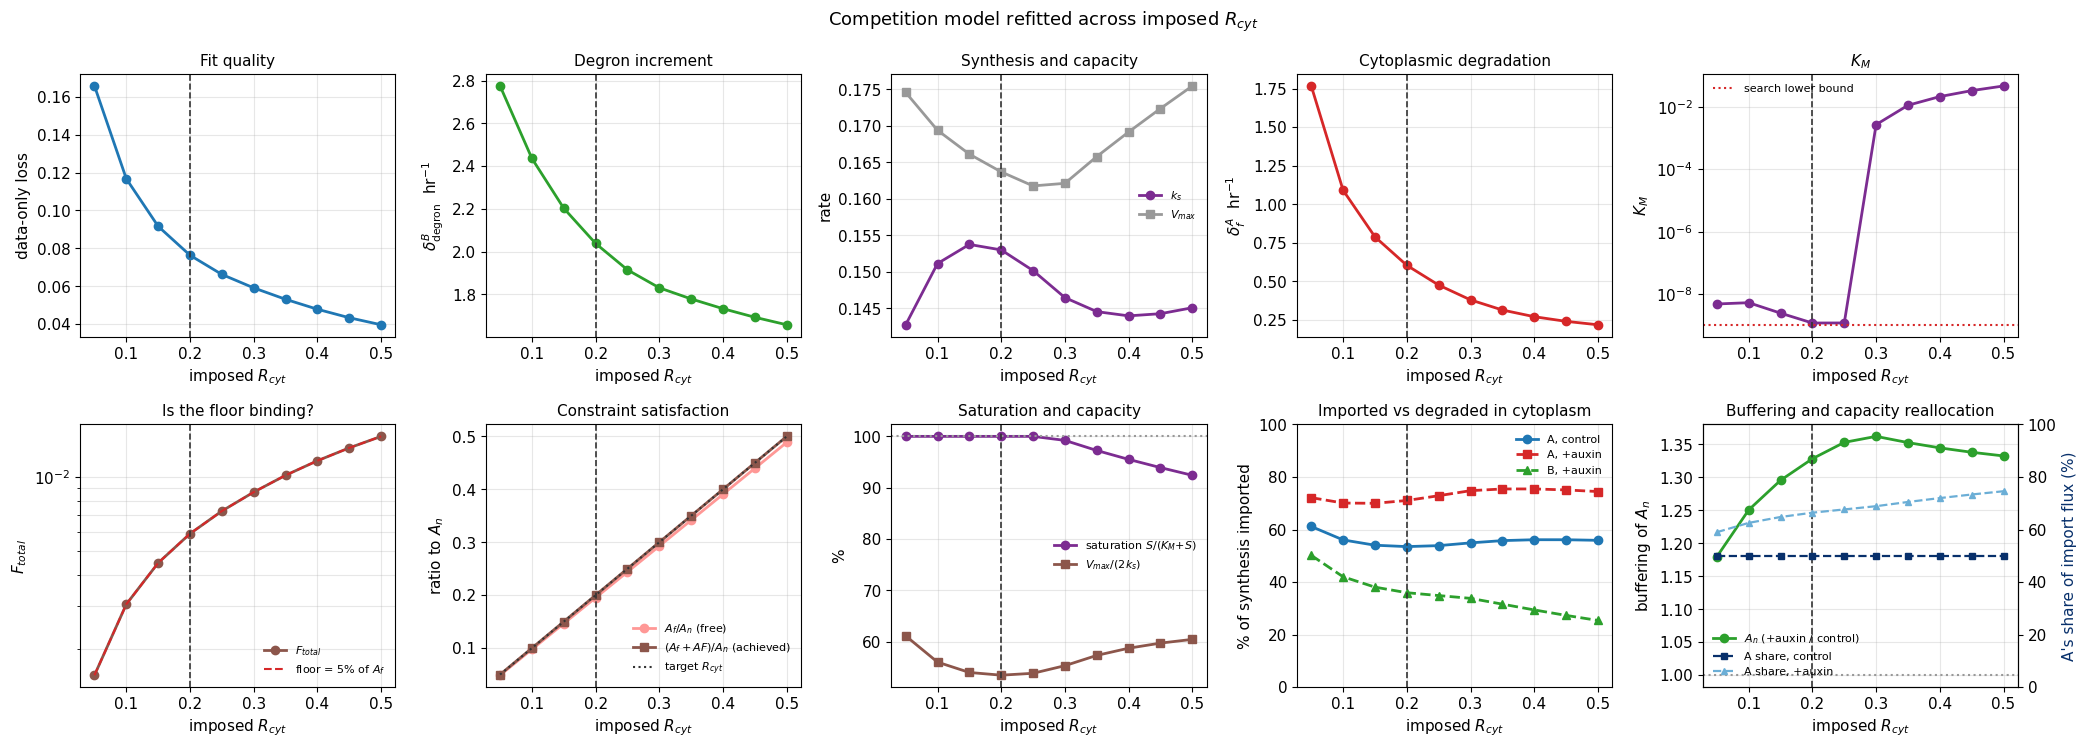

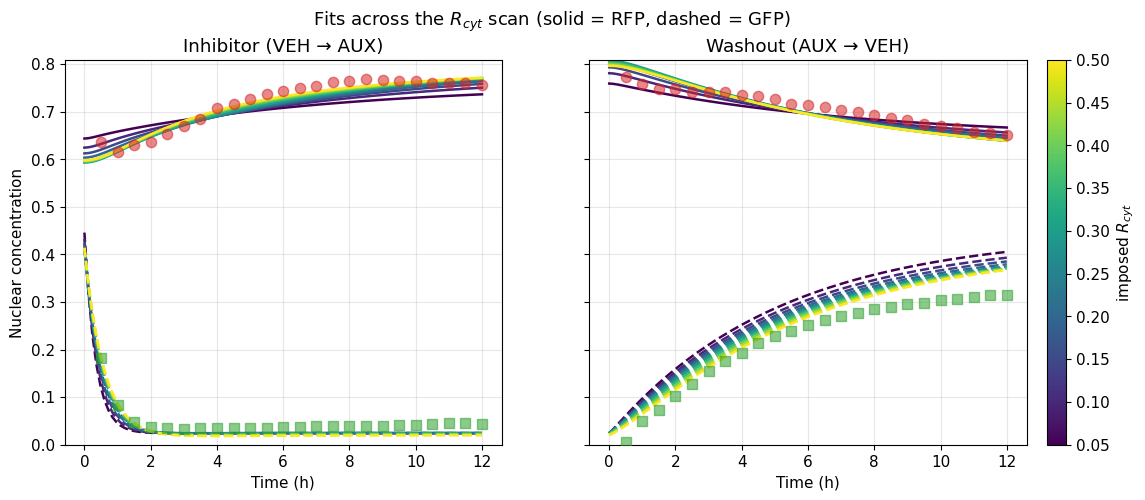

(<Figure size 1300x500 with 3 Axes>,
 array([<Axes: title={'center': 'Inhibitor (VEH → AUX)'}, xlabel='Time (h)', ylabel='Nuclear concentration'>,
        <Axes: title={'center': 'Washout (AUX → VEH)'}, xlabel='Time (h)'>],
       dtype=object))

In [23]:
plot_sweep(
    scan,
    key="R",
    xlabel="imposed $R_{cyt}$",
    logx=False,
    vline=CYTO_NUC_RATIO,
    suptitle="Competition model refitted across imposed $R_{cyt}$",
    savepath="competition_Rcyt_scan.pdf",
)

# Fits across the scan, overlaid on the data
plot_sweep_fits(
    scan_thetas,
    ratios={R: R for R in R_VALUES},
    cbar_label="imposed $R_{cyt}$",
    suptitle="Fits across the $R_{cyt}$ scan (solid = RFP, dashed = GFP)",
    logcm=False,
)

$F_\mathrm{total}$ sits on its floor at every $R_\mathrm{cyt}$. A smaller $F_\mathrm{total}$
means less of the cytoplasmic signal is bound, so $A_f/A_n$ sits as close to $R_\mathrm{cyt}$
as the constraint allows, which makes import as slow as possible relative to the cytoplasmic pool.

$F_\mathrm{total}$ sits on its floor at every $R_\mathrm{cyt}$. This is important for maintaining
competition, so the fit keeping always pushes it as low as the floor allows.

The achieved $(A_f + AF)/A_n$ is equal to the target ratio at
every point, so the constraint is satisfied throughout.

The fit improves as $R_{\mathrm{cyt}}$ increases. The
reason is that $\delta_{\mathrm{degron}}$ is applied equally in both compartments, so it is
trying to satisfy two things at once, and these push in opposite directions. This becomes more
apparent at lower $R_{\mathrm{cyt}}$.
In the nucleus, $\delta_{\mathrm{degron}}$ determines the initial loss of $B_n$ upon auxin
addition, but in order for $A_n$ to rise, $B_{f}$ must fall to release import capacity. Because

$$
B_f = \frac{k_s}{V_{\max}/D + \delta_f^B},
$$

this only happens once $\delta_f^B = \delta_f^A + \delta_{\mathrm{degron}}$ becomes comparable
to $V_{\max}/D$.

How far apart the two requirements sit depends on $R_{\mathrm{cyt}}$. At steady state the nuclear
balance for $A_n$ gives $A_f/A_n = \delta_n^A D / V_{\max}$, so the free cytoplasmic:nuclear ratio is
just the ratio of two residence times (how long a protein waits in the cytoplasm before import,
and how long it survives in the nucleus). Since the constraint sets that ratio to
$R_{\mathrm{cyt}}$ up to the correction from bound protein, imposing a low value means

$$
V_{\max}/D \approx \delta_n^A / R_{\mathrm{cyt}}
$$

is large, so import is fast, and most protein
reaches the nucleus before cytoplasmic degradation has much effect on it. The degron then has to
be considerably larger before it depletes $B_f$ at all.

This is a limitation of assuming the degron acts equally in both compartments rather than of the
competition mechanism itself. Allowing the two rates to differ would remove the conflict, at the
cost of a sixth free parameter that the data cannot separately constrain.

The fitted $K_M$ panel should not be over-interpreted at this stage, and will be investigated
below.

### Dependence on $K_M$

$K_M$ is poorly constrained by the data as it appears to have little influence on the fit. We now investigate how the recovered parameters, the saturation and capacity of the import step, and the partitioning of newly synthesised protein between import and cytoplasmic degradation all vary with different (imposed) $K_M$, compared to the one from the best fit.

In [13]:
K_M_VALUES = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

# R_cyt is held fixed for this sweep; K_M is fixed at each point and the remaining
# four parameters are refitted.
K_M_SWEEP_R = CYTO_NUC_RATIO

bounds_log_KM = [b for i, b in enumerate(bounds_log) if i != 2]  # drop K_M
PARAM_NAMES_KM = ["k_s", "V_max", "delta_f_A", "delta_n_B_degron"]


def _theta_with_KM(theta4_log, K_M_fixed):
    """Insert the fixed K_M into a 4-parameter (log10) coordinate vector."""
    k_s_, V_max_, delta_f_A_ = 10.0 ** np.asarray(theta4_log[:3])
    return np.array([k_s_, V_max_, K_M_fixed, delta_f_A_, theta4_log[3]])


def _to_log_KM(theta):
    """Full 5-parameter theta -> 4-parameter optimizer coordinates (K_M dropped)."""
    k_s_, V_max_, _, delta_f_A_, degron_ = theta
    return np.array([np.log10(k_s_), np.log10(V_max_), np.log10(delta_f_A_), degron_])


def _objective_KM(theta4_log, data_averaged, K_M_fixed, cyto_nuc_ratio):
    return objective_function(
        _theta_with_KM(theta4_log, K_M_fixed),
        data_averaged,
        cyto_nuc_ratio=cyto_nuc_ratio,
    )


km_rows = []
km_thetas = {}
theta_prev = np.asarray(
    scan_thetas.get(K_M_SWEEP_R, best_params_array), dtype=float
).copy()

for K_M_fixed in K_M_VALUES:
    t0 = time.perf_counter()

    result_global_KM = differential_evolution(
        _objective_KM,
        bounds_log_KM,
        args=(data_averaged, K_M_fixed, K_M_SWEEP_R),
        maxiter=SCAN_DE_MAXITER,
        popsize=SCAN_DE_POPSIZE,
        seed=RANDOM_SEED,
        workers=1,
        updating="deferred",
        tol=1e-6,
    )

    best = (np.inf, None)
    starts = [
        _theta_with_KM(result_global_KM.x, K_M_fixed),
        theta_prev,
        best_params_array,
    ]
    for x0 in starts:
        try:
            res = minimize(
                _objective_KM,
                _to_log_KM(x0),
                args=(data_averaged, K_M_fixed, K_M_SWEEP_R),
                method="L-BFGS-B",
                bounds=bounds_log_KM,
            )
        except Exception:
            continue
        if res.fun < best[0]:
            best = (res.fun, _theta_with_KM(res.x, K_M_fixed))

    theta_best = best[1] if best[1] is not None else theta_prev
    km_thetas[K_M_fixed] = theta_best
    theta_prev = theta_best

    d = fit_diagnostics(theta_best, cyto_nuc_ratio=K_M_SWEEP_R)
    d["K_M_fixed"] = K_M_fixed
    km_rows.append(d)

    print(
        f"K_M = {K_M_fixed:8.1e}:  data loss = {d['data_loss']:.5f}  "
        f"k_s = {d['k_s']:.4f}  V_max = {d['V_max']:.4f}  "
        f"delta_f_A = {d['delta_f_A']:.4f}  degron = {d['delta_n_B_degron']:.3f}"
        f"{'  (F_total on floor)' if d['F_total'] <= 1.01 * d['F_floor'] else ''}"
        f"   [{time.perf_counter() - t0:.1f}s]"
    )

km_summary = summarise_sweep(km_rows, km_thetas, "K_M_fixed")
print("\nK_M sweep complete.")

K_M =  1.0e-10:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6043  degron = 2.038  (F_total on floor)   [32.2s]
K_M =  1.0e-09:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6043  degron = 2.038  (F_total on floor)   [33.6s]
K_M =  1.0e-08:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6043  degron = 2.038  (F_total on floor)   [29.9s]
K_M =  1.0e-07:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6042  degron = 2.038  (F_total on floor)   [29.3s]
K_M =  1.0e-06:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6044  degron = 2.038  (F_total on floor)   [31.2s]
K_M =  1.0e-05:  data loss = 0.07635  k_s = 0.1530  V_max = 0.1637  delta_f_A = 0.6044  degron = 2.038  (F_total on floor)   [30.3s]
K_M =  1.0e-04:  data loss = 0.07640  k_s = 0.1531  V_max = 0.1638  delta_f_A = 0.6047  degron = 2.039  (F_total on floor)   [30.4s]
K_M =  1.0e-03:  data loss = 0.07687  k_s = 0.1533  V_max = 0.1647  d

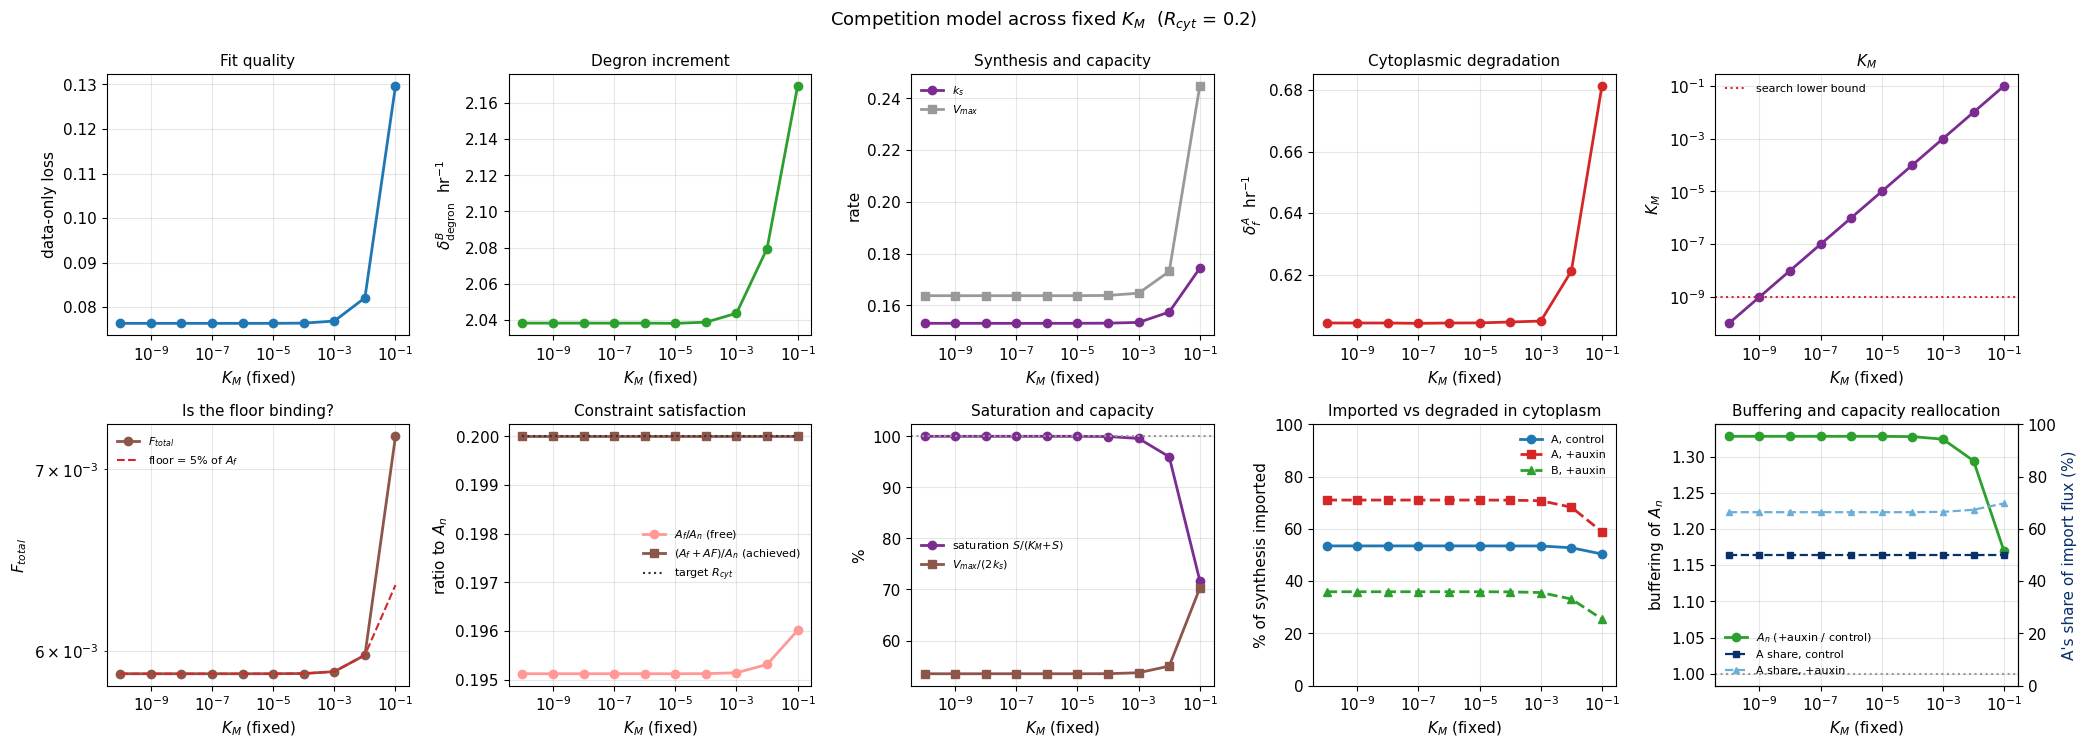

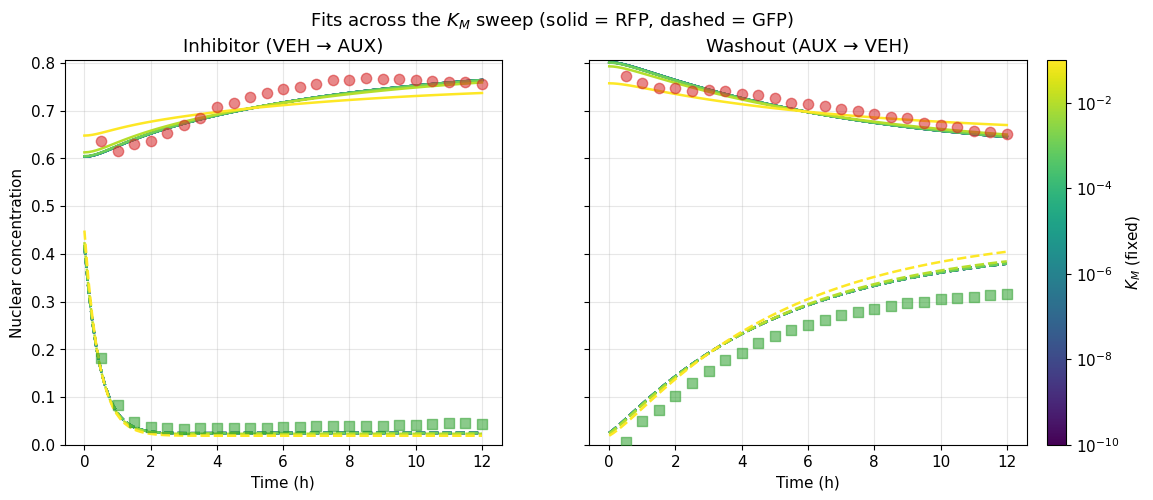

(<Figure size 1300x500 with 3 Axes>,
 array([<Axes: title={'center': 'Inhibitor (VEH → AUX)'}, xlabel='Time (h)', ylabel='Nuclear concentration'>,
        <Axes: title={'center': 'Washout (AUX → VEH)'}, xlabel='Time (h)'>],
       dtype=object))

In [24]:
plot_sweep(
    km_summary,
    key="K_M_fixed",
    xlabel="$K_M$ (fixed)",
    logx=True,
    vline=None,
    suptitle=f"Competition model across fixed $K_M$  ($R_{{cyt}}$ = {K_M_SWEEP_R})",
    savepath="plots/competition_KM_scan.pdf",
)

# Fits across the sweep, overlaid on the data (same helper as the R_cyt sweep)
plot_sweep_fits(
    km_thetas,
    ratios={v: K_M_SWEEP_R for v in K_M_VALUES},
    cbar_label="$K_M$ (fixed)",
    suptitle="Fits across the $K_M$ sweep (solid = RFP, dashed = GFP)",
)

### Select a final $K_M$

The loss is unchanged for $K_M \lesssim 10^{-3}$, so $K_M$ is not identifiable
from these data. We select one near the top so that the reported $K_M$ is
the most conservative (least competitive) choice consistent with the data,
and quote it as a bound rather than an estimate.


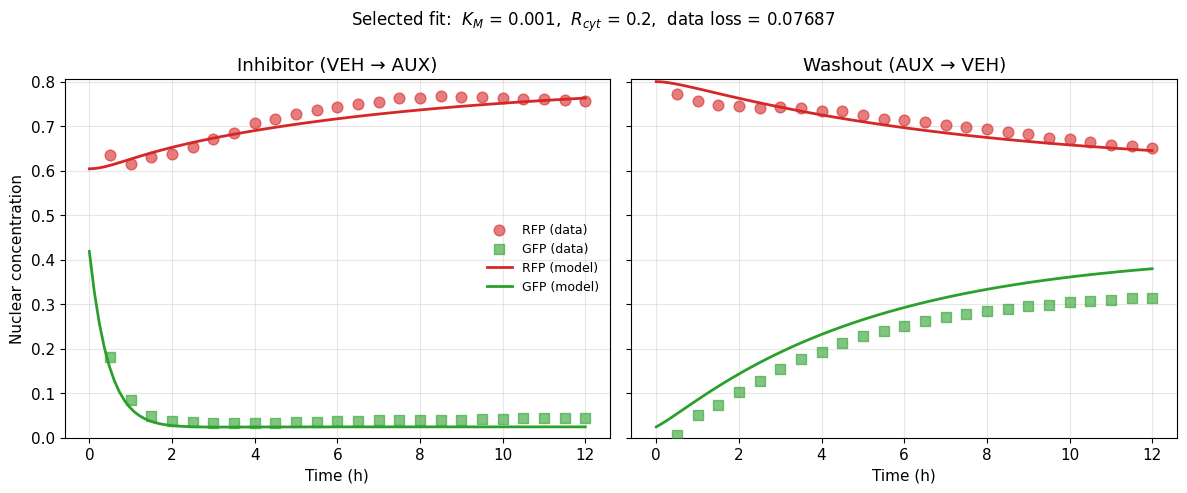

Selected K_M = 0.001   (R_cyt = 0.2)
  data loss   = 0.07687
  k_s         = 0.1533 hr⁻¹
  V_max       = 0.1647
  delta_f_A   = 0.6050 hr⁻¹
  degron      = 2.0437 hr⁻¹
  F_total     = 0.005898   k_import = 27.92 hr⁻¹
  saturation  = 99.6%   capacity/synthesis = 53.7%
  buffering   = 1.324

Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/competition_params_R0_2_manual_K_M.json


In [ ]:
K_M_SELECTED = 1e-3

if K_M_SELECTED not in km_thetas:
    K_M_SELECTED = min(
        km_thetas, key=lambda v: abs(np.log10(v) - np.log10(K_M_SELECTED))
    )
    print(f"Requested K_M not in the sweep; using nearest value {K_M_SELECTED:g}\n")

theta_sel = km_thetas[K_M_SELECTED]
k_s_sel, V_max_sel, K_M_sel, delta_f_A_sel, degron_sel = theta_sel
diag_sel = fit_diagnostics(theta_sel, cyto_nuc_ratio=K_M_SWEEP_R)

# --- plot the selected fit against the data ---
_, preds_sel = objective_function(
    theta_sel, data_averaged, return_predictions=True, cyto_nuc_ratio=K_M_SWEEP_R
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code]
    pred = preds_sel[code]
    ax.scatter(
        d["time"],
        d["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        zorder=3,
        label="RFP (data)",
    )
    ax.scatter(
        d["time"],
        d["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        zorder=3,
        label="GFP (data)",
    )
    ax.plot(pred["time"], pred["A_n"], color=colors["rfp"], lw=2, label="RFP (model)")
    ax.plot(pred["time"], pred["B_n"], color=colors["gfp"], lw=2, label="GFP (model)")
    ax.set_xlabel("Time (h)")
    ax.set_title(titles[code])
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(
    f"Selected fit:  $K_M$ = {K_M_SELECTED:g},  $R_{{cyt}}$ = {K_M_SWEEP_R},  "
    f"data loss = {diag_sel['data_loss']:.5f}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("competition_selected_fit_R0_2.pdf", bbox_inches="tight")
plt.show()

print(f"Selected K_M = {K_M_SELECTED:g}   (R_cyt = {K_M_SWEEP_R})")
print(f"  data loss   = {diag_sel['data_loss']:.5f}")
print(f"  k_s         = {k_s_sel:.4f} hr⁻¹")
print(f"  V_max       = {V_max_sel:.4f}")
print(f"  delta_f_A   = {delta_f_A_sel:.4f} hr⁻¹")
print(f"  degron      = {degron_sel:.4f} hr⁻¹")
print(
    f"  F_total     = {diag_sel['F_total']:.4g}   k_import = {diag_sel['k_import']:.4g} hr⁻¹"
)
print(
    f"  saturation  = {100*diag_sel['saturation']:.1f}%   "
    f"capacity/synthesis = {100*V_max_sel/(2*k_s_sel):.1f}%"
)
print(f"  buffering   = {diag_sel['buffering']:.3f}")

# --- save ---
selected_params = {
    "k_s": k_s_sel,
    "V_max": V_max_sel,
    "k_import": diag_sel["k_import"],
    "F_total": diag_sel["F_total"],
    "K_M": K_M_sel,
    "delta_f_A": delta_f_A_sel,
    "delta_n_B_degron": degron_sel,
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
    "cyto_nuc_ratio": K_M_SWEEP_R,
    "f_total_floor_frac": F_TOTAL_FLOOR_FRAC,
    "data_loss": diag_sel["data_loss"],
}

selected_path = Path("fitted_parameters/competition_params_R0_2_manual_K_M.json")
save_parameters(selected_params, selected_path)
print(f"\nSaved parameters to: {selected_path.resolve()}")

## Checking the QSSA

The derivation required two conditions, (i) $\lambda_1 \gg$ every slow rate and
(ii) $\varepsilon \ll 1$. We check both here against the fitted parameters.

The complication is that $k_\mathrm{off}$ is not identifiable from these data (only $K_M$ and
$k_\mathrm{import}$ are) so conditions must hold across a reasonable range of 
$k_\mathrm{off} \ge 0$

- (i) $\lambda_1 = k_\mathrm{off} + k_\mathrm{import}$ increases with $k_\mathrm{off}$, so the limit
of irreversible binding ($k_\mathrm{off} \to 0$) is the worst case for (i). Even in this case,
the condition is satisfied because $k_\mathrm{import}$ by itself exceeds the fastest of the slow rates.
- (ii) $\varepsilon$ depends on the free pools through $D$, so it must be checked in the perturbed
condition as well as the control (reduction in $B$ lowers $D$ and raises $\varepsilon$).

The first cell below evaluates both conditions across $k_\mathrm{off}$. The second integrates the
full six-species system, with the complexes tracked explicitly and no QSSA applied, and compares it
against the reduced fit.

Slow rates the complexes must equilibrate faster than (hr^-1):
    k_s / A_f              =     1.300
    delta_f^A              =     0.605
    delta_f^B (+auxin)     =     2.649
    delta_n^A              =     0.136
    delta_n^B (+auxin)     =     2.239
    --> max                =     2.649

saturation  S/(K_M+S)            = 99.58%
amplification 1 + S/K_M          = 236.9
sequestration eps = F_tot/(K_M+S)= 0.02489   (2.49% of protein)
free factor F_f                  = 2.489e-05

At k_off = 0:  lambda_1 = 27.92 hr^-1 (10.5x max_slow_rate),  lambda_2 = 6614 hr^-1 (2497x max_slow_rate)
Both relaxation rates already exceed 10x the fastest of the slow processes across the whole scanned k_off range.


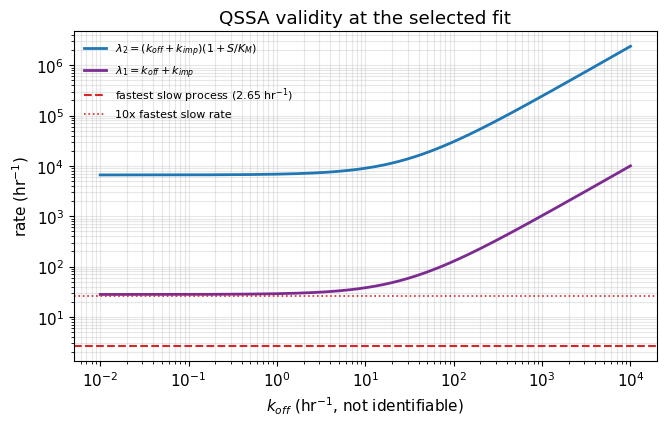

In [26]:
p_sel = {
    "k_s": k_s_sel,
    "k_import": V_max_sel,
    "F_total": 1.0,
    "K_M": K_M_sel,
    "delta_f_A": delta_f_A_sel,
}
ss_sel = competition_steady_state(p_sel, delta_f_A_sel, DELTA_N_A, DELTA_N_B)
A_f_s, B_f_s = ss_sel[0], ss_sel[1]
S_sel = A_f_s + B_f_s
D_sel = K_M_sel + S_sel

k_import_sel = diag_sel["k_import"]
F_total_sel = diag_sel["F_total"]
F_f_sel = F_total_sel * K_M_sel / D_sel  # free factor at the control steady state

# Slow rates the complexes must equilibrate faster than
slow_rates = {
    "k_s / A_f": k_s_sel / A_f_s,
    "delta_f^A": delta_f_A_sel,
    "delta_f^B (+auxin)": delta_f_A_sel + degron_sel,
    "delta_n^A": DELTA_N_A,
    "delta_n^B (+auxin)": DELTA_N_B + degron_sel,
}
max_slow_rate = max(slow_rates.values())

# Reactant-stationary parameter: fraction of cytoplasmic protein held in complex.
# Rate-constant free, so it bounds the QSSA error independently of k_off.
eps_seq = F_total_sel / D_sel

print("Slow rates the complexes must equilibrate faster than (hr^-1):")
for name, val in slow_rates.items():
    print(f"    {name:22s} = {val:9.3f}")
print(f"    {'--> max':22s} = {max_slow_rate:9.3f}\n")
print(f"saturation  S/(K_M+S)            = {100 * S_sel / D_sel:.2f}%")
print(f"amplification 1 + S/K_M          = {1 + S_sel / K_M_sel:.4g}")
print(
    f"sequestration eps = F_tot/(K_M+S)= {eps_seq:.4g}   ({100 * eps_seq:.2f}% of protein)"
)
print(f"free factor F_f                  = {F_f_sel:.4g}\n")

# Candidate rates as a function of the unidentifiable k_off
k_off_grid = np.logspace(-2, 4, 400)
lam_1 = k_off_grid + k_import_sel  # complex loss
lam_2 = lam_1 * (1.0 + S_sel / K_M_sel)  # second (faster) mode

FACTOR = 10.0
worst = lam_1
ok = worst >= FACTOR * max_slow_rate
k_off_min = k_off_grid[ok][0] if ok.any() else np.inf

print(
    f"At k_off = 0:  lambda_1 = {k_import_sel:.4g} hr^-1 "
    f"({k_import_sel / max_slow_rate:.1f}x max_slow_rate),  "
    f"lambda_2 = {k_import_sel * (1 + S_sel / K_M_sel):.4g} hr^-1 "
    f"({k_import_sel * (1 + S_sel / K_M_sel) / max_slow_rate:.0f}x max_slow_rate)"
)
if k_off_min <= k_off_grid[0]:
    print(
        f"Both relaxation rates already exceed {FACTOR:.0f}x the fastest of the slow processes "
        f"across the whole scanned k_off range."
    )
elif np.isfinite(k_off_min):
    print(
        f"Both relaxation rates exceed {FACTOR:.0f}x the fastest of the slow processes "
        f"once k_off >= {k_off_min:.3g} hr^-1."
    )
else:
    print(f"No k_off in the scanned range reaches {FACTOR:.0f}x.")

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.plot(
    k_off_grid,
    lam_2,
    color="#1f77b4",
    lw=2,
    label=r"$\lambda_2 = (k_{off}+k_{imp})(1+S/K_M)$",
)
ax.plot(
    k_off_grid, lam_1, color="#7c2c91", lw=2, label=r"$\lambda_1 = k_{off}+k_{imp}$"
)

ax.axhline(
    max_slow_rate,
    color="#d62728",
    ls="--",
    lw=1.5,
    label=f"fastest slow process ({max_slow_rate:.2f} hr$^{{-1}}$)",
)
ax.axhline(
    FACTOR * max_slow_rate,
    color="#d62728",
    ls=":",
    lw=1.2,
    label=f"{FACTOR:.0f}x fastest slow rate",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$k_{off}$ (hr$^{-1}$, not identifiable)")
ax.set_ylabel("rate (hr$^{-1}$)")
ax.set_title("QSSA validity at the selected fit")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("competition_qssa_validity.pdf", bbox_inches="tight")
plt.show()

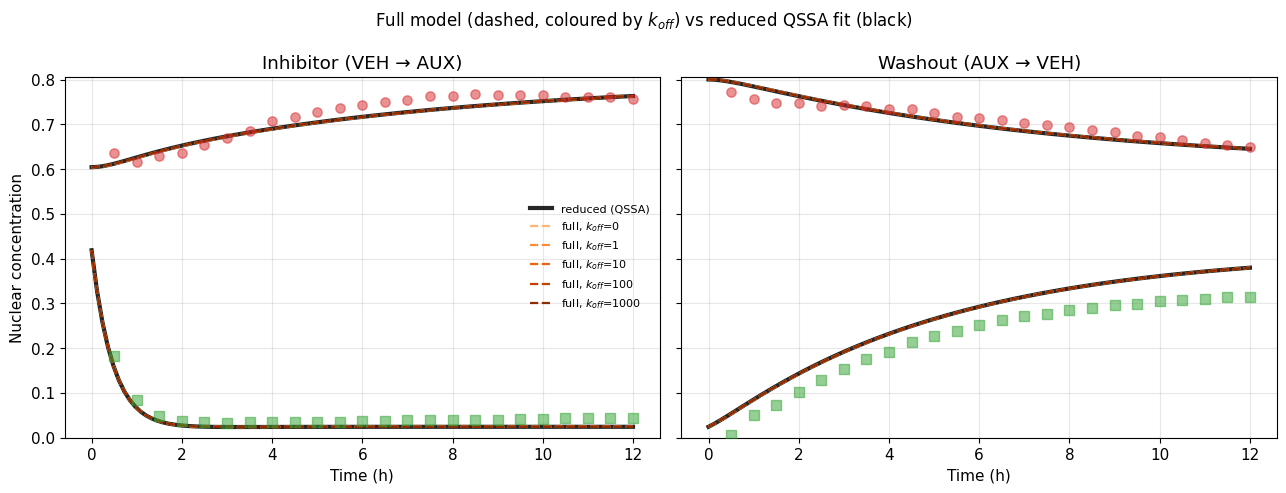


Max |full - reduced| over the fitting window (nuclear A and B):
 k_off (hr^-1)         abs    % of control A_n
           0.0      0.0029               0.47%
           1.0      0.0029               0.47%
          10.0      0.0029               0.48%
         100.0      0.0029               0.48%
        1000.0      0.0029               0.49%

Predicted bound from sequestration: eps = 0.02489 (2.49%).


In [ ]:
# Full six-species model (no QSSA) vs the reduced fit

FULL_ATOL, FULL_RTOL = 1e-10, 1e-9
SS_T_END = 3000.0


def full_model(t, y, k_off, delta_f_B, delta_n_B):
    """Unreduced system: complexes AF, BF tracked explicitly."""
    A_f, B_f, AF, BF, A_n, B_n = y
    k_on = (k_off + k_import_sel) / K_M_sel
    F_f = F_total_sel - AF - BF
    a_on, b_on = k_on * A_f * F_f, k_on * B_f * F_f
    return [
        k_s_sel - a_on + k_off * AF - delta_f_A_sel * A_f,
        k_s_sel - b_on + k_off * BF - delta_f_B * B_f,
        a_on - (k_off + k_import_sel) * AF,
        b_on - (k_off + k_import_sel) * BF,
        k_import_sel * AF - DELTA_N_A * A_n,
        k_import_sel * BF - delta_n_B * B_n,
    ]


def _full_y0_from_reduced(delta_f_B, delta_n_B):
    """QSSA steady state, expanded to the six-species state vector."""
    ss = competition_steady_state(p_sel, delta_f_B, DELTA_N_A, delta_n_B)
    A_f, B_f, A_n, B_n = ss
    D = K_M_sel + A_f + B_f
    return [A_f, B_f, F_total_sel * A_f / D, F_total_sel * B_f / D, A_n, B_n]


def _integrate_full(y0, k_off, delta_f_B, delta_n_B, t_end, n_points=None):
    kwargs = {} if n_points is None else {"t_eval": np.linspace(0.0, t_end, n_points)}
    sol = solve_ivp(
        full_model,
        (0.0, t_end),
        y0,
        args=(k_off, delta_f_B, delta_n_B),
        method="LSODA",
        atol=FULL_ATOL,
        rtol=FULL_RTOL,
        **kwargs,
    )
    if not sol.success:
        raise RuntimeError(f"full model failed at k_off={k_off}: {sol.message}")
    return sol.t, sol.y


def full_condition(k_off, code, t_end, n_points=200):
    """
    Full-model trajectory for one experimental condition, driven exactly as the
    reduced model is: VEH_AUX starts at the control steady state and runs
    perturbed rates; AUX_VEH starts at the perturbed steady state and runs
    control rates. Each starting steady state is found by relaxing the full
    model from the corresponding QSSA steady state.
    """
    control = (delta_f_A_sel, DELTA_N_B)
    perturbed = (delta_f_A_sel + degron_sel, DELTA_N_B + degron_sel)
    start, run = (control, perturbed) if code == "VEH_AUX" else (perturbed, control)

    _, y_ss = _integrate_full(_full_y0_from_reduced(*start), k_off, *start, SS_T_END)
    return _integrate_full(y_ss[:, -1], k_off, *run, t_end, n_points=n_points)


# Span three orders of magnitude, including the k_off -> 0 (irreversible) worst case
K_OFF_TEST = [0.0, 1.0, 10.0, 100.0, 1000.0]

# reduced-model (QSSA) predictions
_, preds_red = objective_function(
    theta_sel, data_averaged, return_predictions=True, cyto_nuc_ratio=K_M_SWEEP_R
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
shades = plt.cm.Oranges(np.linspace(0.35, 0.95, len(K_OFF_TEST)))
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}
max_err = {}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code]
    t_end = d["time"].max()
    ax.scatter(d["time"], d["rfp"], color="#d62728", alpha=0.5, s=45, zorder=4)
    ax.scatter(
        d["time"], d["gfp"], color="#2ca02c", alpha=0.5, s=45, marker="s", zorder=4
    )
    ax.plot(
        preds_red[code]["time"],
        preds_red[code]["A_n"],
        color="#000000",
        lw=3,
        alpha=0.85,
        label="reduced (QSSA)",
    )
    ax.plot(
        preds_red[code]["time"],
        preds_red[code]["B_n"],
        color="#000000",
        lw=3,
        alpha=0.85,
    )

    for k_off, c in zip(K_OFF_TEST, shades):
        t, y = full_condition(k_off, code, t_end)
        ax.plot(t, y[4], color=c, lw=1.6, ls="--", label=f"full, $k_{{off}}$={k_off:g}")
        ax.plot(t, y[5], color=c, lw=1.6, ls="--")
        for idx, key in [(4, "A_n"), (5, "B_n")]:
            red = np.interp(t, preds_red[code]["time"], preds_red[code][key])
            max_err[k_off] = max(max_err.get(k_off, 0.0), np.max(np.abs(y[idx] - red)))

    ax.set_xlabel("Time (h)")
    ax.set_title(titles[code])
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(
    "Full model (dashed, coloured by $k_{off}$) vs reduced QSSA fit (black)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("competition_full_vs_qssa.pdf", bbox_inches="tight")
plt.show()

A_n_ctrl = ss_sel[2]
print("\nMax |full - reduced| over the fitting window (nuclear A and B):")
print(f"{'k_off (hr^-1)':>14}  {'abs':>10}  {'% of control A_n':>18}")
for k_off in K_OFF_TEST:
    print(
        f"{k_off:14.1f}  {max_err[k_off]:10.4f}  {100 * max_err[k_off] / A_n_ctrl:17.2f}%"
    )
print(
    f"\nPredicted bound from sequestration: eps = {eps_seq:.4g} ({100 * eps_seq:.2f}%)."
)

## Validation on steady-state timecourse data

Neither constant-treatment condition was used to fit the data. In the model,
both are just steady states. VEH_VEH sits at the control steady state, 
and AUX_AUX at the perturbed steady state.


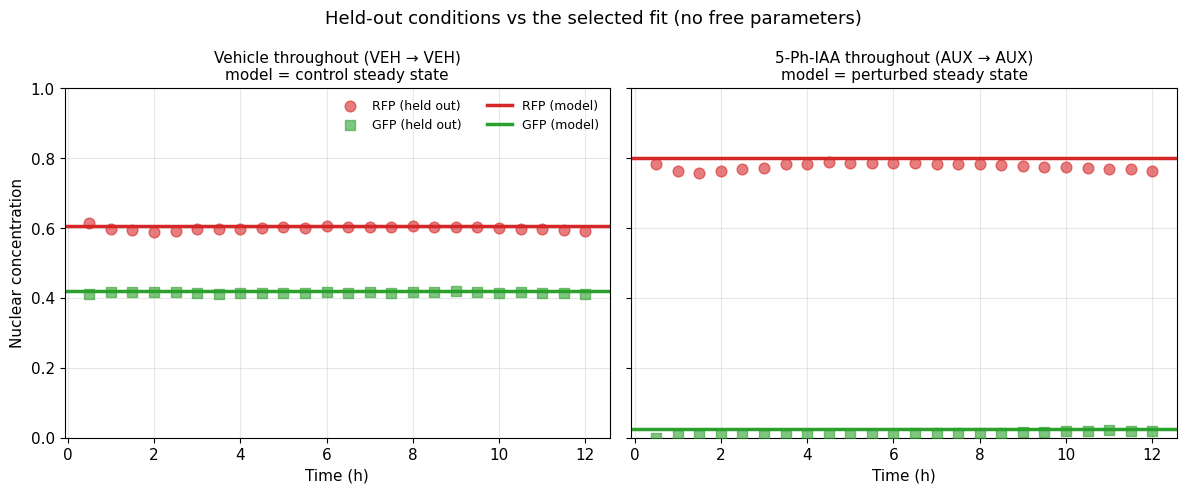

condition  channel      model   data mean      bias      RMSE   RMSE (%)
VEH_VEH    RFP         0.6044      0.5994   -0.0050    0.0073       1.2%
VEH_VEH    GFP         0.4188      0.4153   -0.0035    0.0038       0.9%
AUX_AUX    RFP         0.8003      0.7766   -0.0237    0.0253       3.2%
AUX_AUX    GFP         0.0244      0.0124   -0.0120    0.0131      53.7%

Buffering of nuclear A (mCherry), +auxin / control:
    model      = 1.324
    held-out   = 1.296   (AUX_AUX mean / VEH_VEH mean)


In [29]:
ss_ctrl_sel = competition_steady_state(p_sel, delta_f_A_sel, DELTA_N_A, DELTA_N_B)
ss_pert_sel = competition_steady_state(
    p_sel, delta_f_A_sel + degron_sel, DELTA_N_A, DELTA_N_B + degron_sel
)

holdout_pred = {
    "VEH_VEH": {
        "A_n": ss_ctrl_sel[2],
        "B_n": ss_ctrl_sel[3],
        "state": "control steady state",
    },
    "AUX_AUX": {
        "A_n": ss_pert_sel[2],
        "B_n": ss_pert_sel[3],
        "state": "perturbed steady state",
    },
}
holdout_titles = {
    "VEH_VEH": "Vehicle throughout (VEH → VEH)",
    "AUX_AUX": "5-Ph-IAA throughout (AUX → AUX)",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, code_ in zip(axes, HOLDOUT_CONDITIONS):
    d = data_holdout[code_]
    pred = holdout_pred[code_]
    ax.scatter(
        d["time"],
        d["rfp"],
        color="#d62728",
        alpha=0.6,
        s=60,
        zorder=3,
        label="RFP (held out)",
    )
    ax.scatter(
        d["time"],
        d["gfp"],
        color="#2ca02c",
        alpha=0.6,
        s=60,
        marker="s",
        zorder=3,
        label="GFP (held out)",
    )
    ax.axhline(pred["A_n"], color="#d62728", lw=2.5, label="RFP (model)")
    ax.axhline(pred["B_n"], color="#2ca02c", lw=2.5, label="GFP (model)")
    ax.set_xlabel("Time (h)")
    ax.set_title(f"{holdout_titles[code_]}\nmodel = {pred['state']}", fontsize=11)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
axes[0].legend(frameon=False, fontsize=9, ncol=2)
fig.suptitle(
    "Held-out conditions vs the selected fit (no free parameters)", fontsize=13
)
plt.tight_layout()
plt.savefig("competition_holdout_validation.pdf", bbox_inches="tight")
plt.show()

print(
    f"{'condition':<10} {'channel':<8} {'model':>9} {'data mean':>11} "
    f"{'bias':>9} {'RMSE':>9} {'RMSE (%)':>10}"
)
for code_ in HOLDOUT_CONDITIONS:
    d = data_holdout[code_]
    for channel, key in [("RFP", "A_n"), ("GFP", "B_n")]:
        obs = d["rfp"].to_numpy() if channel == "RFP" else d["gfp"].to_numpy()
        mu = holdout_pred[code_][key]
        rmse = float(np.sqrt(np.mean((obs - mu) ** 2)))
        print(
            f"{code_:<10} {channel:<8} {mu:9.4f} {obs.mean():11.4f} "
            f"{obs.mean() - mu:9.4f} {rmse:9.4f} {100 * rmse / max(mu, EPS_RATIO):9.1f}%"
        )

# The buffering claim, stated directly against held-out data
obs_ratio = (
    data_holdout["AUX_AUX"]["rfp"].mean() / data_holdout["VEH_VEH"]["rfp"].mean()
)
print(
    f"\nBuffering of nuclear A (mCherry), +auxin / control:\n"
    f"    model      = {diag_sel['buffering']:.3f}\n"
    f"    held-out   = {obs_ratio:.3f}   (AUX_AUX mean / VEH_VEH mean)"
)